In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoMinorLocator
from scipy.signal import butter, filtfilt
from IPython.display import display, clear_output
import ipywidgets as widgets
from scipy.optimize import curve_fit

from utils.db_utils import *
from utils.movie_utils import get_movie_parameters
from utils.paths_utils import resolve_sta_paths

In [ ]:
home_dir = Path(r"Z:\\Adam-Lab-Shared\\Data\\Miki_Meerson\\Imaging\\HYP-JEDI\\Hyp3\\L\\02-02-2026-awake\\FOV1\\z-18-x2")
paths = resolve_sta_paths(home_dir)
sta_dir = paths.sta_dir

neuron_dataset_path = sta_dir / DEFAULT_NEURON_DATASET_NAME
cluster_dataset_path = sta_dir / DEFAULT_CLUSTER_DATASET_NAME
kinetics_dataset_path = sta_dir / "cluster_dataset_with_kinetics.pkl"

movie_params = get_movie_parameters(f"{home_dir.as_posix()}/", is_dir=True)
fps = int(movie_params["fps"])
print(f"FPS: {fps}")
neuron_df, cluster_df = load_normalized_dataset(
    cluster_dataset_path=cluster_dataset_path,
    neuron_dataset_path=neuron_dataset_path,
)

print("Loaded neuron_df:", neuron_df.shape)
print("Loaded cluster_df:", cluster_df.shape)

combined_df = combine_neuron_cluster_tables(neuron_df, cluster_df)
print("Combined shape:", combined_df.shape)
display(combined_df.head(3))

FPS: 29
Loaded neuron_df: (87, 3)
Loaded cluster_df: (10475, 9)
Combined shape: (10475, 19)


,cage,mouse_name,recording_date,behavior,recording_name,neuron_id,cluster_id,sign,is_significant,p_value,disqualify_latency,latency_shared_peak_frame_for_kinetics,all_mean_trace,simple_mean_trace,complex_mean_trace,traces_inverted_for_negative_gevi,all_peak_frames,simple_peak_frames,complex_peak_frames
0,Hyp3,L,02-02-2026,awake,z-18-x2,0,1,negative,True,0.039801,True,NaN,"[-1.6231648, -1.6123773, -1.592973, -1.6068976...","[-1.6367038, -1.6018376, -1.5912666, -1.604967...","[-1.5943953, -1.6347744, -1.5965992, -1.610999...",True,"[62, 655, 1009, 1289, 1399, 1520, 2110, 2612, ...","[62, 655, 1009, 1289, 1399, 1520, 2110, 2612, ...","[3074, 4119, 4704, 5473, 5975, 6906, 7252, 8205]"
1,Hyp3,L,02-02-2026,awake,z-18-x2,0,2,negative,False,0.223881,True,NaN,"[-1.0383127, -1.0571078, -1.0254444, -1.056614...","[-1.0322626, -1.0448396, -1.0122784, -1.040024...","[-1.051169, -1.0831777, -1.053422, -1.0918663,...",True,"[62, 655, 1009, 1289, 1399, 1520, 2110, 2612, ...","[62, 655, 1009, 1289, 1399, 1520, 2110, 2612, ...","[3074, 4119, 4704, 5473, 5975, 6906, 7252, 8205]"
2,Hyp3,L,02-02-2026,awake,z-18-x2,0,3,negative,False,0.601990,True,NaN,"[-1.5986373, -1.57511, -1.5720077, -1.5780939,...","[-1.5980833, -1.5592852, -1.5716552, -1.575060...","[-1.5998149, -1.6087383, -1.5727571, -1.584538...",True,"[62, 655, 1009, 1289, 1399, 1520, 2110, 2612, ...","[62, 655, 1009, 1289, 1399, 1520, 2110, 2612, ...","[3074, 4119, 4704, 5473, 5975, 6906, 7252, 8205]"


In [3]:
neuron_key_cols = [
    c
    for c in [
        "cage",
        "mouse_name",
        "recording_date",
        "behavior",
        "recording_name",
        "neuron_id",
    ]
    if c in combined_df.columns
]

neuron_spike_flags = (
    combined_df.assign(
        has_simple=combined_df["simple_peak_frames"].map(lambda peaks: len(peaks) > 0),
        has_complex=combined_df["complex_peak_frames"].map(lambda peaks: len(peaks) > 0),
    )
    .groupby(neuron_key_cols, dropna=False, as_index=False)[["has_simple", "has_complex"]]
    .any()
)

neurons_with_both_spikes = neuron_spike_flags.loc[
    neuron_spike_flags["has_simple"] & neuron_spike_flags["has_complex"], neuron_key_cols
]

significant_clusters_both_spikes = (
    combined_df.loc[combined_df["is_significant"].astype(bool)]
    .merge(neurons_with_both_spikes, on=neuron_key_cols, how="inner")
    .copy()
)

total_neurons = combined_df[neuron_key_cols].drop_duplicates().shape[0]
total_clusters = len(combined_df)  # one row per cluster in combined_df

print(f"Neurons with both simple and complex spikes: {len(neurons_with_both_spikes)}/{len(neuron_df)}")
print(f"Significant clusters from those neurons: {len(significant_clusters_both_spikes)}/{len(combined_df)}")

Neurons with both simple and complex spikes: 81/87
Significant clusters from those neurons: 128/10475


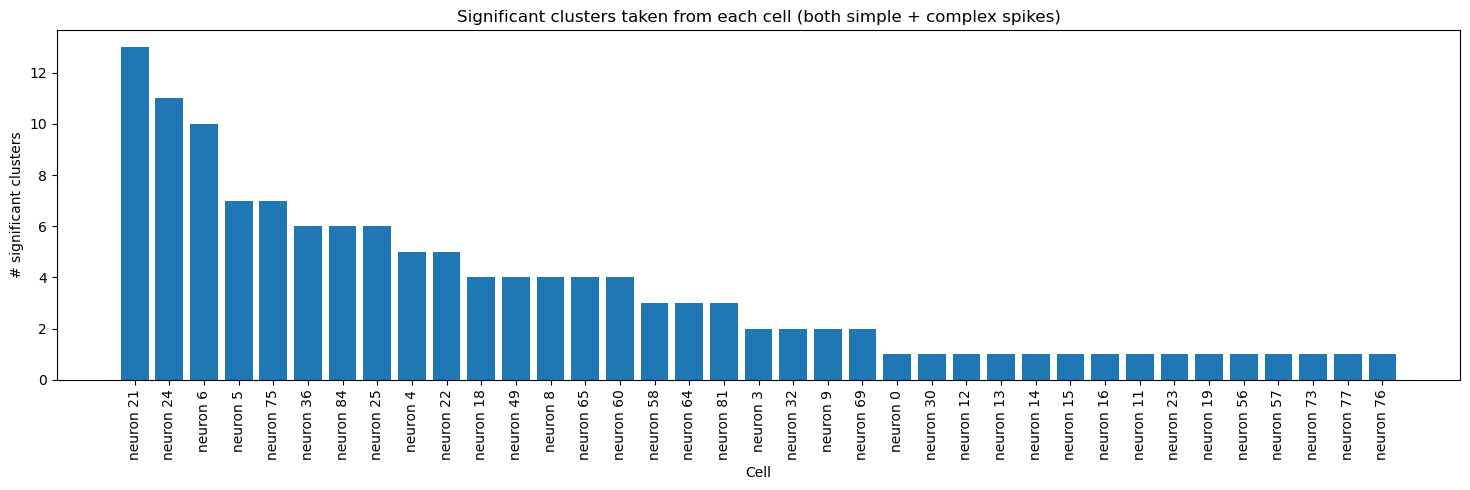

In [4]:
if significant_clusters_both_spikes.empty:
    print("No significant clusters found for neurons with both simple and complex spikes.")
else:
    sig_clusters_per_cell = (
        significant_clusters_both_spikes
        .groupby(neuron_key_cols, dropna=False)
        .size()
        .reset_index(name="n_sig_clusters")
    )

    sig_clusters_per_cell["cell_label"] = "neuron " + sig_clusters_per_cell["neuron_id"].astype(str)
    sig_clusters_per_cell = sig_clusters_per_cell.sort_values("n_sig_clusters", ascending=False)

    plt.figure(figsize=(max(10, 0.4 * len(sig_clusters_per_cell)), 5))
    plt.bar(sig_clusters_per_cell["cell_label"], sig_clusters_per_cell["n_sig_clusters"])
    plt.xticks(rotation=90)
    plt.ylabel("# significant clusters")
    plt.xlabel("Cell")
    plt.title("Significant clusters taken from each cell (both simple + complex spikes)")
    plt.tight_layout()
    plt.show()

# Build kinetics dataset

In [14]:
trace_cols = neuron_key_cols + ["cluster_id", "simple_mean_trace", "complex_mean_trace"]

cluster_traces_df = (
    significant_clusters_both_spikes[trace_cols]
    .dropna(subset=["simple_mean_trace", "complex_mean_trace"])
    .copy()
)

if cluster_traces_df.empty:
    print("No valid simple/complex traces to plot.")
else:
    print(f"Extracted traces for {len(cluster_traces_df)} significant clusters.")

Extracted traces for 128 significant clusters.


## Preprocessing of a trace for kinetics estimation

In [ ]:
example = cluster_traces_df.iloc[1]

neuron_id = int(example['neuron_id'])
neuron_dir = sta_dir / f"cell_{neuron_id}"
meta = load_sta_metadata(neuron_dir)
pre_frames = int(meta["pre_frames"])
post_frames = int(meta["post_frames"])
rel_frames = get_rel_frames(neuron_id, sta_dir)

simple_trace = np.asarray(example["simple_mean_trace"], dtype=float)
complex_trace = np.asarray(example["complex_mean_trace"], dtype=float)

plt.figure(figsize=(8, 4))
plt.plot(rel_frames, simple_trace - np.mean(simple_trace), label="Simple trace", linewidth=2)
plt.plot(rel_frames, complex_trace - np.mean(complex_trace), label="Complex trace", linewidth=2)
plt.axvline(0, linestyle='--', color='k', alpha=0.2)
plt.xlabel("Frame")
plt.ylabel("Signal")
plt.title(
    f"Example cluster: neuron {neuron_id}, cluster {int(example['cluster_id'])}"
)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
def smooth_except_large_responses(
    trace,
    window=9,
    sigma=2.0,
    z_high=2.5,          # seed threshold (peak core)
    z_low=1.2,           # grow threshold (peak shoulders)
    protect_radius=3,    # extra padding around detected regions
):
    x = np.asarray(trace, dtype=float)
    if x.ndim != 1:
        raise ValueError("trace must be 1D")
    if window < 1:
        raise ValueError("window must be >= 1")
    if window % 2 == 0:
        window += 1

    # smoothing kernel
    half = window // 2
    t = np.arange(-half, half + 1, dtype=float)
    kernel = np.exp(-0.5 * (t / sigma) ** 2)
    kernel /= kernel.sum()

    pad = window // 2
    y_smooth = np.convolve(np.pad(x, pad, mode="reflect"), kernel, mode="valid")

    # robust z-score
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    scale = 1.4826 * mad if mad > 0 else (np.nanstd(x) + 1e-12)
    z = np.abs((x - med) / (scale + 1e-12))

    # hysteresis mask: start at strong points, grow through weaker neighbors
    strong = z >= z_high
    weak = z >= z_low
    mask = np.zeros_like(strong, dtype=bool)

    idx = np.where(strong)[0]
    for i in idx:
        l = i
        while l - 1 >= 0 and weak[l - 1]:
            l -= 1
        r = i
        while r + 1 < len(x) and weak[r + 1]:
            r += 1
        mask[l:r + 1] = True

    # optional dilation
    if protect_radius > 0 and mask.any():
        out = np.zeros_like(mask, dtype=bool)
        for i in np.where(mask)[0]:
            l = max(0, i - protect_radius)
            r = min(len(mask), i + protect_radius + 1)
            out[l:r] = True
        mask = out

    y = y_smooth.copy()
    y[mask] = x[mask]
    return y, mask


In [8]:
def compute_rise_decay_times(y, t_axis=None):
    y = np.asarray(y, dtype=float)
    t = np.asarray(t_axis, dtype=float) if t_axis is not None else np.arange(len(y), dtype=float)

    n0 = max(3, len(y)//10)
    baseline_idx = np.arange(n0)
    baseline = np.mean(y[baseline_idx])

    # choose largest deflection from baseline (handles positive/negative)
    peak_idx = int(np.argmax(np.abs(y - baseline)))

    ypeak = y[peak_idx]
    sign = 1.0 if (ypeak - baseline) >= 0 else -1.0
    ys = sign * (y - baseline)  # response-aligned positive signal

    A = ys[peak_idx]
    if A <= 0:
        raise ValueError("No valid peak above baseline")

    y10 = 0.1 * A
    y90 = 0.9 * A

    def interp_crossing(t, ys, level, start, end, direction):
        for i in range(start, end):
            y1, y2 = ys[i], ys[i+1]
            if direction == "rising":
                cond = (y1 <= level) and (y2 >= level)
            else:
                cond = (y1 >= level) and (y2 <= level)
            if cond:
                if y2 == y1:
                    return t[i]
                return t[i] + (level - y1) * (t[i+1] - t[i]) / (y2 - y1)
        return np.nan

    t10_rise = interp_crossing(t, ys, y10, 0, peak_idx, "rising")
    t90_rise = interp_crossing(t, ys, y90, 0, peak_idx, "rising")
    t90_decay = interp_crossing(t, ys, y90, peak_idx + 1, len(y) - 1, "falling")
    t10_decay = interp_crossing(t, ys, y10, peak_idx + 1, len(y) - 1, "falling")

    return {
        "baseline": baseline,
        "peak_time": t[peak_idx],
        "peak_value": ypeak,
        "rise_time_10_90": t90_rise - t10_rise,
        "decay_time_90_10": t10_decay - t90_decay,
        "t10_rise": t10_rise,
        "t90_rise": t90_rise,
        "t90_decay": t90_decay,
        "t10_decay": t10_decay,
    }


In [9]:
def compute_trace_kinetics(trace, rel_frames, zoom=True, zoom_pre_frames=30, zoom_post_frames=30):
    # step 1 - zoom to response window
    if zoom:
        rel_frames = np.arange(-zoom_pre_frames, zoom_post_frames + 1, dtype=np.int32)
        trace = trace[(pre_frames-zoom_pre_frames):(pre_frames + zoom_post_frames + 1)]

    # step 2 - Center and smooth trace
    trace -= np.mean(trace)
    smooth_trace, mask = smooth_except_large_responses(trace)

    # step 3 - Compute rise and decay kinetics
    kinetics = compute_rise_decay_times(smooth_trace, t_axis=rel_frames)

    return kinetics, smooth_trace, rel_frames, mask

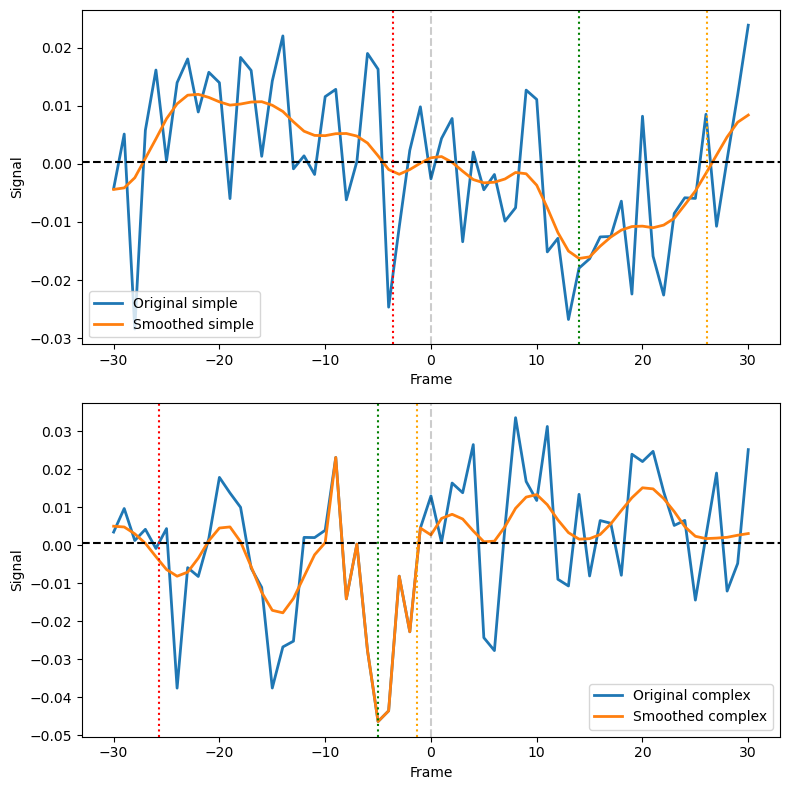

In [ ]:
zoom_pre_frames = 30
zoom_post_frames = 30
zoom_rel_frames = np.arange(-zoom_pre_frames, zoom_post_frames + 1, dtype=np.int32)

zoom_simple_trace = simple_trace[(pre_frames-zoom_pre_frames):(pre_frames + zoom_post_frames + 1)]
zoom_complex_trace = complex_trace[(pre_frames-zoom_pre_frames):(pre_frames + zoom_post_frames + 1)]

kinetics_simple, smooth_simple, rel_frames_simple, mask_simple  = compute_trace_kinetics(simple_trace, rel_frames)
kinetics_complex, smooth_complex, rel_frames_complex, mask_complex = compute_trace_kinetics(complex_trace, rel_frames)

fig, axes = plt.subplots(2, 1, figsize=(8, 8)) 
axes[0].plot(zoom_rel_frames, zoom_simple_trace, label="Original simple", linewidth=2)
axes[0].plot(zoom_rel_frames, smooth_simple, label="Smoothed simple", linewidth=2)
axes[0].axvline(0, linestyle='--', color='k', alpha=0.2)
axes[0].axhline(kinetics_simple["baseline"], color='black', linestyle='--')
axes[0].axvline(kinetics_simple["peak_time"], color="green", linestyle=':')
axes[0].axvline(kinetics_simple["t10_rise"], color="red",linestyle=':')
axes[0].axvline(kinetics_simple["t10_decay"], color="orange", linestyle=':')
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Signal")
axes[0].legend()

axes[1].plot(zoom_rel_frames, zoom_complex_trace, label="Original complex", linewidth=2)
axes[1].plot(zoom_rel_frames, smooth_complex, label="Smoothed complex", linewidth=2)
axes[1].axvline(0, linestyle='--', color='k', alpha=0.2)
axes[1].axhline(kinetics_complex["baseline"], color='black', linestyle='--')
axes[1].axvline(kinetics_complex["peak_time"], color="green", linestyle=':')
axes[1].axvline(kinetics_complex["t10_rise"], color="red",linestyle=':')
axes[1].axvline(kinetics_complex["t10_decay"], color="orange", linestyle=':')
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Signal")
axes[1].legend()

plt.tight_layout()
plt.show()

## Preprocessing of trace for kinetics estimation V2

In [15]:
def fit_exp_rise_decay(rel_frames, trace, peak_index, baseline=None):
    """
    Constrained exp fits that meet at peak and share one baseline.

    rise:  y = b + (y_peak - b) * exp(-(t_peak - t)/tau_r),   t <= t_peak
    decay: y = b + (y_peak - b) * exp(-(t - t_peak)/tau_d),   t >= t_peak
    """
    t = np.asarray(rel_frames, dtype=float)
    y = np.asarray(trace, dtype=float)
    peak_index = int(peak_index)

    if not (0 < peak_index < len(y) - 1):
        raise ValueError("peak_index must be inside the window, not at edges.")

    # baseline from pre-0 frames (or fallback)
    if baseline is None:
        pre = y[t < 0]
        baseline = float(np.median(pre)) if pre.size >= 3 else float(np.median(y[:max(3, len(y)//5)]))

    t_peak = float(t[peak_index])
    y_peak = float(y[peak_index])

    # keep same polarity by flipping if negative-going response
    sign = 1.0 if (y_peak - baseline) >= 0 else -1.0
    ys = sign * (y - baseline)
    y_peak_s = sign * (y_peak - baseline)  # positive

    if y_peak_s <= 0:
        raise ValueError("Peak is not above baseline after alignment.")

    idx = np.arange(len(t))
    rise_mask = idx <= peak_index
    decay_mask = idx >= peak_index

    t_r = t[rise_mask]
    y_r = ys[rise_mask]
    t_d = t[decay_mask]
    y_d = ys[decay_mask]

    if len(t_r) < 4 or len(t_d) < 4:
        raise ValueError("Need at least 4 points on each side of peak.")

    eps = 1e-9

    def rise_model(tt, tau):
        return y_peak_s * np.exp(-(t_peak - tt) / np.maximum(tau, eps))

    def decay_model(tt, tau):
        return y_peak_s * np.exp(-(tt - t_peak) / np.maximum(tau, eps))

    tau_r0 = max((t_peak - t_r[0]) / 3.0, 1.0)
    tau_d0 = max((t_d[-1] - t_peak) / 3.0, 1.0)

    tau_r, _ = curve_fit(rise_model, t_r, y_r, p0=[tau_r0], bounds=([eps], [np.inf]), maxfev=20000)
    tau_d, _ = curve_fit(decay_model, t_d, y_d, p0=[tau_d0], bounds=([eps], [np.inf]), maxfev=20000)

    fit_r_s = rise_model(t_r, tau_r[0])
    fit_d_s = decay_model(t_d, tau_d[0])

    # back to original polarity/offset
    fit_r = baseline + sign * fit_r_s
    fit_d = baseline + sign * fit_d_s

    return {
        "baseline": baseline,
        "t_peak": t_peak,
        "peak_index": peak_index,
        "rise": {"tau": float(tau_r[0]), "t": t_r, "fit": fit_r},
        "decay": {"tau": float(tau_d[0]), "t": t_d, "fit": fit_d},
    }

In [16]:
def estimate_rise_decay_bounds_from_fit(t_peak, tau_r, tau_d, frac=0.1):
    if not (0 < frac < 1):
        raise ValueError("frac must be in (0,1)")
    t_rise_start = t_peak + tau_r * np.log(frac)
    t_decay_end = t_peak - tau_d * np.log(frac)
    return t_rise_start, t_decay_end

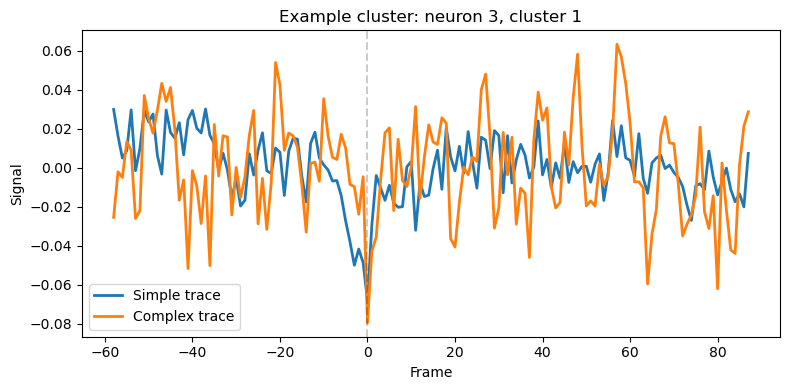

In [17]:
example = cluster_traces_df.iloc[1]

neuron_id = int(example['neuron_id'])
neuron_dir = sta_dir / f"cell_{neuron_id}"
meta = load_sta_metadata(neuron_dir)
pre_frames = int(meta["pre_frames"])
post_frames = int(meta["post_frames"])
rel_frames = get_rel_frames(neuron_id, sta_dir)

simple_trace = np.asarray(example["simple_mean_trace"], dtype=float)
complex_trace = np.asarray(example["complex_mean_trace"], dtype=float)

plt.figure(figsize=(8, 4))
plt.plot(rel_frames, simple_trace - np.mean(simple_trace), label="Simple trace", linewidth=2)
plt.plot(rel_frames, complex_trace - np.mean(complex_trace), label="Complex trace", linewidth=2)
plt.axvline(0, linestyle='--', color='k', alpha=0.2)
plt.xlabel("Frame")
plt.ylabel("Signal")
plt.title(
    f"Example cluster: neuron {neuron_id}, cluster {int(example['cluster_id'])}"
)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\owner\AppData\Local\Temp\ipykernel_18292\1900358286.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc="upper right")


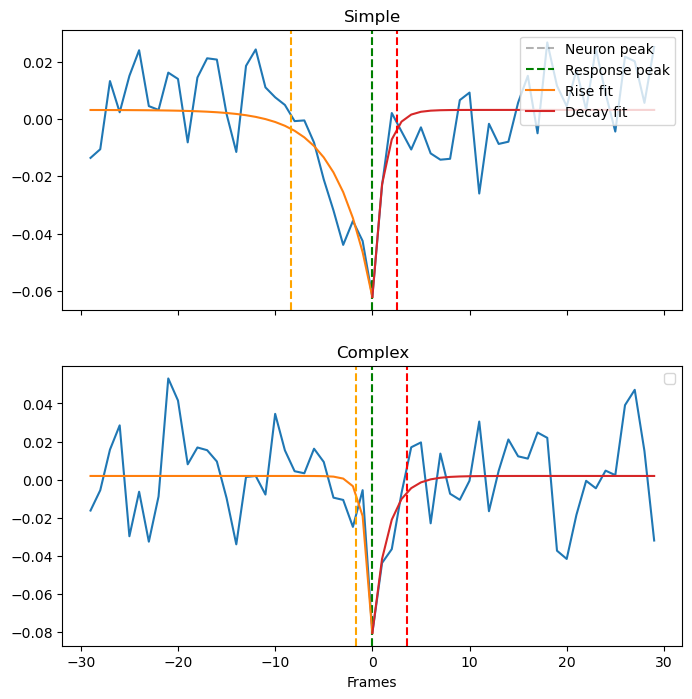

In [18]:
zoom_pre_frames = fps
zoom_post_frames = fps
zoom_rel_frames = np.arange(-zoom_pre_frames, zoom_post_frames + 1, dtype=np.int32)
peak_diff_tol = 3

# step 1 - zoom to relevent window
zoom_simple_trace = simple_trace[(pre_frames-zoom_pre_frames):(pre_frames + zoom_post_frames + 1)]
zoom_complex_trace = complex_trace[(pre_frames-zoom_pre_frames):(pre_frames + zoom_post_frames + 1)]

# step 2 - subtract baseline
zoom_simple_trace -= np.mean(zoom_simple_trace)
zoom_complex_trace -= np.mean(zoom_complex_trace)

# step 3 - find peak of both and validate
peak_simple = int(np.argmax(np.abs(zoom_simple_trace)))
peak_complex = int(np.argmax(np.abs(zoom_complex_trace)))
rel_peak_simple = zoom_rel_frames[peak_simple]
rel_peak_complex = zoom_rel_frames[peak_complex]

if abs(rel_peak_simple - rel_peak_complex) > peak_diff_tol:
    print("Responses peaks not aligned - excluding from analysis")
elif abs(rel_peak_simple) > peak_diff_tol:
    print("Peak response is not around neuron peak - excluding from analysis")
else:
    # step 4 - fit exponential rise and decay
    kinetics_simple = fit_exp_rise_decay(zoom_rel_frames, zoom_simple_trace, peak_simple)
    kinetics_complex = fit_exp_rise_decay(zoom_rel_frames, zoom_complex_trace, peak_complex)

    simple_t_rise_start, simple_t_decay_end = estimate_rise_decay_bounds_from_fit(
        rel_peak_simple,
        kinetics_simple["rise"]["tau"],
        kinetics_simple["decay"]["tau"],
        frac=0.1
    )

    complex_t_rise_start, complex_t_decay_end = estimate_rise_decay_bounds_from_fit(
        rel_peak_complex,
        kinetics_complex["rise"]["tau"],
        kinetics_complex["decay"]["tau"],
        frac=0.1
    )

    fig, axes = plt.subplots(2, 1, figsize=(8,8), sharex=True)

    axes[0].plot(zoom_rel_frames, zoom_simple_trace)
    axes[0].axvline(0, linestyle='--', color='k', alpha=0.3, label="Neuron peak")
    axes[0].axvline(rel_peak_simple, linestyle='--', color='green', label="Response peak")
    axes[0].plot(kinetics_simple["rise"]["t"], kinetics_simple["rise"]["fit"], color="tab:orange", label="Rise fit")
    axes[0].plot(kinetics_simple["decay"]["t"], kinetics_simple["decay"]["fit"], color="tab:red", label="Decay fit")
    axes[0].axvline(simple_t_rise_start, linestyle='--', color='orange')
    axes[0].axvline(simple_t_decay_end, linestyle='--', color='red')
    axes[0].legend(loc="upper right")
    axes[0].set_title("Simple")

    axes[1].plot(zoom_rel_frames, zoom_complex_trace)
    axes[1].axvline(0, linestyle='--', color='k', alpha=0.3)
    axes[1].axvline(rel_peak_complex, linestyle='--', color='green')
    axes[1].plot(kinetics_complex["rise"]["t"], kinetics_complex["rise"]["fit"], color="tab:orange")
    axes[1].plot(kinetics_complex["decay"]["t"], kinetics_complex["decay"]["fit"], color="tab:red")
    axes[1].axvline(complex_t_rise_start, linestyle='--', color='orange')
    axes[1].axvline(complex_t_decay_end, linestyle='--', color='red')
    axes[1].legend(loc="upper right")
    axes[1].set_xlabel("Frames")
    axes[1].set_title("Complex")

## Interactive GUI - kinetics per cluster

In [ ]:
# Build working table from significant clusters with both spike types.
trace_cols = neuron_key_cols + ["cluster_id", "simple_mean_trace", "complex_mean_trace"]
cluster_traces_df = (
    significant_clusters_both_spikes[trace_cols]
    .dropna(subset=["simple_mean_trace", "complex_mean_trace"])
    .reset_index(drop=True)
    .copy()
)

cluster_traces_df["disqualify_reason"] = ""
cluster_traces_df["disqualify_kinetics"] = False

idx_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(cluster_traces_df) - 1,
    step=1,
    description="Cluster",
    continuous_update=False,
    style={"description_width": "80px"},
    layout=widgets.Layout(width="420px"),
)

reason_dropdown = widgets.Dropdown(
    options=[
        ("Include", ""),
        ("Only simple response", "only_simple_response"),
        ("Only complex response", "only_complex_response"),
        ("No response", "no_response"),
    ],
    value="",
    description="Reason",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="340px"),
)

prev_btn = widgets.Button(description="Prev", button_style="")
next_btn = widgets.Button(description="Next", button_style="")
run_btn = widgets.Button(description="Compute + Merge", button_style="success")
out = widgets.Output()

def compute_cluster_kinetics(simple_trace, complex_trace, rel_frames):
    ks, smooth_s, rel_frames_s, _ = compute_trace_kinetics(simple_trace.copy(), rel_frames)
    kc, smooth_c, rel_frames_c, _ = compute_trace_kinetics(complex_trace.copy(), rel_frames)
    return rel_frames_s, smooth_s, smooth_c, ks, kc

def _render(i):
    i = int(i)
    row = cluster_traces_df.iloc[i]

    reason_dropdown.unobserve(_on_reason_change, names="value")
    reason_dropdown.value = str(row["disqualify_reason"])
    reason_dropdown.observe(_on_reason_change, names="value")

    with out:
        clear_output(wait=True)
        print(
            f"Cluster {i+1}/{len(cluster_traces_df)} | neuron {int(row['neuron_id'])}, "
            f"cluster {int(row['cluster_id'])} | reason={row['disqualify_reason'] or 'include'}"
        )
        try:
            simple_trace = np.asarray(row["simple_mean_trace"])
            complex_trace = np.asarray(row["complex_mean_trace"])
            rel_frames = get_rel_frames(row["neuron_id"], sta_dir)
            k_rel_frames, smooth_s, smooth_c, ks, kc = compute_cluster_kinetics(simple_trace, complex_trace, rel_frames)

            fig, axes = plt.subplots(3, 1, figsize=(8, 6))

            axes[0].axvline(0, ls="--", c="k", alpha=0.3)
            axes[0].plot(rel_frames, simple_trace, label="simple")
            axes[0].plot(rel_frames, complex_trace, label="complex")
            axes[0].set_xlabel("Frames")
            axes[0].set_xlim(rel_frames[0], rel_frames[-1])
            axes[0].set_ylabel("Raw")
            axes[0].legend(loc="upper right")

            axes[1].plot(k_rel_frames, smooth_s, lw=2, label="Simple smoothed")
            axes[1].axvline(0, ls="--", c="k", alpha=0.3)
            axes[1].axhline(ks["baseline"], ls="--", c="k", label="baseline")
            axes[1].axvline(ks["t10_rise"], ls=":", c="red", label="t10_rise")
            axes[1].axvline(ks["t10_decay"], ls=":", c="orange", label="t10_decay")
            axes[1].axvline(ks["peak_time"], ls=":", c="green", label="peak time")
            axes[1].set_ylabel("Simple")
            axes[1].legend(loc="upper right")

            axes[2].plot(k_rel_frames, smooth_c, lw=2, label="Complex smoothed")
            axes[2].axvline(0, ls="--", c="k", alpha=0.3)
            axes[2].axhline(kc["baseline"], ls="--", c="k", label="baseline")
            axes[2].axvline(kc["t10_rise"], ls=":", c="red", label="t10_rise")
            axes[2].axvline(kc["t10_decay"], ls=":", c="orange", label="t10_decay")
            axes[2].axvline(kc["peak_time"], ls=":", c="green", label="peak time")
            axes[2].set_ylabel("Complex")
            axes[2].set_xlabel("Frame (t=0 neuron peak)")
            axes[2].set_xlim(k_rel_frames[0], k_rel_frames[-1])
            axes[2].legend(loc="upper right")
            plt.tight_layout()
            plt.show()
            print(
                f"simple: t10_rise={ks['t10_rise']:.3f}, t10_decay={ks['t10_decay']:.3f}, peak_time={ks['peak_time']} | "
                f"complex: t10_rise={kc['t10_rise']:.3f}, t10_decay={kc['t10_decay']:.3f}, peak_time={kc['peak_time']}"
            )
        except Exception as exc:
            print(f"Kinetics failed for this cluster: {exc}")

def _on_reason_change(change):
    i = int(idx_slider.value)
    reason = str(change["new"])
    cluster_traces_df.at[i, "disqualify_reason"] = reason
    cluster_traces_df.at[i, "disqualify_kinetics"] = reason != ""

def _on_idx_change(change):
    _render(change["new"])

def _prev(_):
    idx_slider.value = max(idx_slider.min, idx_slider.value - 1)

def _next(_):
    idx_slider.value = min(idx_slider.max, idx_slider.value + 1)

def _run(_):
    rows = []
    n_ok = 0
    n_fail = 0
    for i, row in cluster_traces_df.iterrows():
        rec = {k: row[k] for k in neuron_key_cols + ["cluster_id"]}
        rec["disqualify_reason"] = str(row["disqualify_reason"])
        rec["disqualify_kinetics"] = bool(rec["disqualify_reason"])

        if rec["disqualify_kinetics"]:
            rec.update(
                {
                    "simple_t10_rise": np.nan,
                    "simple_t10_decay": np.nan,
                    "simple_peak_index": np.nan,
                    "complex_t10_rise": np.nan,
                    "complex_t10_decay": np.nan,
                    "complex_peak_index": np.nan,
                    "kinetics_error": rec["disqualify_reason"],
                }
            )
            rows.append(rec)
            continue

        try:
            simple_trace = np.asarray(row["simple_mean_trace"])
            complex_trace = np.asarray(row["complex_mean_trace"])
            rel_frames = get_rel_frames(row["neuron_id"], sta_dir)
            _, _, _, ks, kc = compute_cluster_kinetics(simple_trace, complex_trace, rel_frames)
            rec.update(
                {
                    "simple_t10_rise": float(ks["t10_rise"]),
                    "simple_t10_decay": float(ks["t10_decay"]),
                    "simple_peak_index": float(ks["peak_time"]),
                    "complex_t10_rise": float(kc["t10_rise"]),
                    "complex_t10_decay": float(kc["t10_decay"]),
                    "complex_peak_index": float(kc["peak_time"]),
                    "kinetics_error": "",
                }
            )
            n_ok += 1
        except Exception as exc:
            rec.update(
                {
                    "simple_t10_rise": np.nan,
                    "simple_t10_decay": np.nan,
                    "simple_peak_index": np.nan,
                    "complex_t10_rise": np.nan,
                    "complex_t10_decay": np.nan,
                    "complex_peak_index": np.nan,
                    "kinetics_error": f"{type(exc).__name__}: {exc}",
                }
            )
            n_fail += 1
        rows.append(rec)

    kinetics_df = pd.DataFrame(rows)
    cluster_traces_with_kinetics = cluster_traces_df.merge(
        kinetics_df,
        on=neuron_key_cols + ["cluster_id", "disqualify_kinetics", "disqualify_reason"],
        how="left",
    )

    combined_df_with_kinetics = combined_df.merge(
        kinetics_df,
        on=neuron_key_cols + ["cluster_id"],
        how="left",
    )

    globals()["kinetics_df"] = kinetics_df
    globals()["cluster_traces_with_kinetics"] = cluster_traces_with_kinetics
    globals()["combined_df_with_kinetics"] = combined_df_with_kinetics

    print(
        f"Done. qualified={n_ok}, failed={n_fail}, disqualified="
        f"{int(kinetics_df['disqualify_kinetics'].sum())}"
    )
    display(kinetics_df.head())
    print("Merged dataset available as: combined_df_with_kinetics")

idx_slider.observe(_on_idx_change, names="value")
reason_dropdown.observe(_on_reason_change, names="value")
prev_btn.on_click(_prev)
next_btn.on_click(_next)
run_btn.on_click(_run)

controls = widgets.HBox([prev_btn, next_btn, idx_slider, reason_dropdown, run_btn])
display(controls)
display(out)
_render(0)

Output()

In [19]:
# Merge kinetics/disqualification into the full cluster-level dataset (combined_df)
merge_keys = neuron_key_cols + ["cluster_id"]

kinetics_cols = merge_keys + [
    "disqualify_reason",
    "disqualify_kinetics",
    "simple_t10_rise",
    "simple_t10_decay",
    "simple_peak_index",
    "complex_t10_rise",
    "complex_t10_decay",
    "complex_peak_index",
    "kinetics_error",
]

# Safety: one row per cluster key
kinetics_unique = kinetics_df[kinetics_cols].drop_duplicates(subset=merge_keys, keep="last").copy()

combined_df_with_kinetics = combined_df.merge(
    kinetics_unique,
    on=merge_keys,
    how="left",
)

print(f"combined_df rows: {len(combined_df)}")
print(f"combined_df_with_kinetics rows: {len(combined_df_with_kinetics)}")
print("New columns added:")
print([c for c in kinetics_cols if c not in merge_keys])

display(combined_df_with_kinetics.head())

# Save to pickle next to existing datasets
combined_df_with_kinetics.to_pickle(kinetics_dataset_path)
print(f"Saved: {kinetics_dataset_path}")

combined_df rows: 10475
combined_df_with_kinetics rows: 10475
New columns added:
['disqualify_reason', 'disqualify_kinetics', 'simple_t10_rise', 'simple_t10_decay', 'simple_peak_index', 'complex_t10_rise', 'complex_t10_decay', 'complex_peak_index', 'kinetics_error']


,cage,mouse_name,recording_date,behavior,recording_name,neuron_id,cluster_id,sign,is_significant,p_value,...,complex_peak_frames,disqualify_reason,disqualify_kinetics,simple_t10_rise,simple_t10_decay,simple_peak_index,complex_t10_rise,complex_t10_decay,complex_peak_index,kinetics_error
0,Hyp3,L,02-02-2026,awake,z-18-x2,0,1,negative,True,0.039801,...,"[3074, 4119, 4704, 5473, 5975, 6906, 7252, 8205]",no_response,True,NaN,NaN,NaN,NaN,NaN,NaN,no_response
1,Hyp3,L,02-02-2026,awake,z-18-x2,0,2,negative,False,0.223881,...,"[3074, 4119, 4704, 5473, 5975, 6906, 7252, 8205]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Hyp3,L,02-02-2026,awake,z-18-x2,0,3,negative,False,0.601990,...,"[3074, 4119, 4704, 5473, 5975, 6906, 7252, 8205]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Hyp3,L,02-02-2026,awake,z-18-x2,0,4,negative,False,0.646766,...,"[3074, 4119, 4704, 5473, 5975, 6906, 7252, 8205]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Hyp3,L,02-02-2026,awake,z-18-x2,0,5,positive,False,0.661692,...,"[3074, 4119, 4704, 5473, 5975, 6906, 7252, 8205]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved: Z:\Adam-Lab-Shared\Data\Miki_Meerson\Imaging\HYP-JEDI\Hyp3\L\02-02-2026-awake\FOV1\z-18-x2\sta_analysis\cluster_dataset_with_kinetics.pkl


## Interactive GUI - kinetics per cluster V2

In [19]:
# V2 interactive GUI: exponential-fit kinetics
trace_cols = neuron_key_cols + ["cluster_id", "simple_mean_trace", "complex_mean_trace"]
cluster_traces_df_v2 = (
    significant_clusters_both_spikes[trace_cols]
    .dropna(subset=["simple_mean_trace", "complex_mean_trace"])
    .reset_index(drop=True)
    .copy()
)

cluster_traces_df_v2["disqualify_reason"] = ""
cluster_traces_df_v2["disqualify_kinetics"] = False

zoom_pre_frames_v2 = 20
zoom_post_frames_v2 = 20
peak_diff_tol_v2 = 3

idx_slider_v2 = widgets.IntSlider(
    value=0,
    min=0,
    max=max(0, len(cluster_traces_df_v2) - 1),
    step=1,
    description="Cluster",
    continuous_update=False,
    style={"description_width": "80px"},
    layout=widgets.Layout(width="420px"),
)

reason_dropdown_v2 = widgets.Dropdown(
    options=[
        ("Include", ""),
        ("Only simple response", "only_simple_response"),
        ("Only complex response", "only_complex_response"),
        ("No response", "no_response"),
        ("Peak misaligned", "peak_misaligned"),
        ("Peak far from zero", "peak_far_from_zero"),
        ("Fit failed", "fit_failed"),
    ],
    value="",
    description="Reason",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="360px"),
)

prev_btn_v2 = widgets.Button(description="Prev")
next_btn_v2 = widgets.Button(description="Next")
run_btn_v2 = widgets.Button(description="Compute + Merge V2", button_style="success")
out_v2 = widgets.Output()

def _zoom_around_zero(trace, rel_frames, pre_n, post_n):
    tr = np.asarray(trace, dtype=float)
    rf = np.asarray(rel_frames, dtype=int)
    if len(tr) != len(rf):
        raise ValueError(f"trace/rel_frames length mismatch: {len(tr)} vs {len(rf)}")
    center = int(np.argmin(np.abs(rf)))
    i0 = max(0, center - int(pre_n))
    i1 = min(len(tr), center + int(post_n) + 1)
    return rf[i0:i1], tr[i0:i1]

def compute_cluster_kinetics_exp_v2(simple_trace, complex_trace, rel_frames):
    zrf_s, zsimple = _zoom_around_zero(simple_trace, rel_frames, zoom_pre_frames_v2, zoom_post_frames_v2)
    zrf_c, zcomplex = _zoom_around_zero(complex_trace, rel_frames, zoom_pre_frames_v2, zoom_post_frames_v2)

    # enforce same x-axis span
    n = min(len(zrf_s), len(zrf_c))
    zrf = zrf_s[:n]
    zsimple = zsimple[:n].copy()
    zcomplex = zcomplex[:n].copy()

    zsimple -= np.nanmean(zsimple)
    zcomplex -= np.nanmean(zcomplex)

    peak_simple = int(np.nanargmax(np.abs(zsimple)))
    peak_complex = int(np.nanargmax(np.abs(zcomplex)))
    rel_peak_simple = int(zrf[peak_simple])
    rel_peak_complex = int(zrf[peak_complex])

    if abs(rel_peak_simple - rel_peak_complex) > peak_diff_tol_v2:
        raise ValueError("peak_misaligned")
    if abs(rel_peak_simple) > peak_diff_tol_v2 or abs(rel_peak_complex) > peak_diff_tol_v2:
        raise ValueError("peak_far_from_zero")

    fit_half = max(4, int(fps // 2))
    ks = fit_exp_rise_decay(zrf, zsimple, peak_simple)
    kc = fit_exp_rise_decay(zrf, zcomplex, peak_complex)

    return {
        "zrf": zrf,
        "zsimple": zsimple,
        "zcomplex": zcomplex,
        "peak_simple": peak_simple,
        "peak_complex": peak_complex,
        "rel_peak_simple": rel_peak_simple,
        "rel_peak_complex": rel_peak_complex,
        "ks": ks,
        "kc": kc,
    }

def _estimate_bounds_from_tau(t_peak, tau_r, tau_d, frac=0.1):
    if not (0 < frac < 1):
        raise ValueError("frac must be in (0,1)")
    t_rise_start = float(t_peak + tau_r * np.log(frac))
    t_decay_end = float(t_peak - tau_d * np.log(frac))
    return t_rise_start, t_decay_end

def _auto_reason_from_exc(exc):
    msg = str(exc).lower()
    if "peak_misaligned" in msg:
        return "peak_misaligned"
    if "peak_far_from_zero" in msg:
        return "peak_far_from_zero"
    return "fit_failed"

def _render_v2(i):
    i = int(i)
    row = cluster_traces_df_v2.iloc[i]

    reason_dropdown_v2.unobserve(_on_reason_change_v2, names="value")
    reason_dropdown_v2.value = str(row["disqualify_reason"])
    reason_dropdown_v2.observe(_on_reason_change_v2, names="value")

    with out_v2:
        clear_output(wait=True)
        print(
            f"[V2] Cluster {i+1}/{len(cluster_traces_df_v2)} | neuron {int(row['neuron_id'])}, "
            f"cluster {int(row['cluster_id'])} | reason={row['disqualify_reason'] or 'include'}"
        )

        # Always prepare raw traces so they can be visualized even if fit fails.
        simple_trace = np.asarray(row["simple_mean_trace"], dtype=float)
        complex_trace = np.asarray(row["complex_mean_trace"], dtype=float)
        rel_frames = get_rel_frames(int(row["neuron_id"]), sta_dir)

        zrf_raw, zsimple_raw = _zoom_around_zero(simple_trace, rel_frames, zoom_pre_frames_v2, zoom_post_frames_v2)
        zrf_raw2, zcomplex_raw = _zoom_around_zero(complex_trace, rel_frames, zoom_pre_frames_v2, zoom_post_frames_v2)
        n = min(len(zrf_raw), len(zrf_raw2))
        zrf_raw = zrf_raw[:n]
        zsimple_raw = zsimple_raw[:n].copy()
        zcomplex_raw = zcomplex_raw[:n].copy()
        zsimple_raw -= np.nanmean(zsimple_raw)
        zcomplex_raw -= np.nanmean(zcomplex_raw)

        peak_simple_raw = int(np.nanargmax(np.abs(zsimple_raw)))
        peak_complex_raw = int(np.nanargmax(np.abs(zcomplex_raw)))
        rel_peak_simple_raw = int(zrf_raw[peak_simple_raw])
        rel_peak_complex_raw = int(zrf_raw[peak_complex_raw])

        fit_ok = True
        fit_err = None
        k = None

        try:
            k = compute_cluster_kinetics_exp_v2(simple_trace, complex_trace, rel_frames)
        except Exception as exc:
            fit_ok = False
            fit_err = exc
            auto_reason = _auto_reason_from_exc(exc)
            cluster_traces_df_v2.at[i, "disqualify_reason"] = auto_reason
            cluster_traces_df_v2.at[i, "disqualify_kinetics"] = True
            reason_dropdown_v2.unobserve(_on_reason_change_v2, names="value")
            reason_dropdown_v2.value = auto_reason
            reason_dropdown_v2.observe(_on_reason_change_v2, names="value")

        fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

        # Always plot raw traces
        axes[0].plot(zrf_raw, zsimple_raw, label="simple raw", color="tab:blue")
        axes[0].axvline(0, ls="--", c="k", alpha=0.3)
        axes[0].axvline(rel_peak_simple_raw, ls=":", c="green", label="response peak")
        axes[0].set_ylabel("Simple")

        axes[1].plot(zrf_raw, zcomplex_raw, label="complex raw", color="tab:blue")
        axes[1].axvline(0, ls="--", c="k", alpha=0.3)
        axes[1].axvline(rel_peak_complex_raw, ls=":", c="green", label="response peak")
        axes[1].set_ylabel("Complex")
        axes[1].set_xlabel("Frames")

        # Overlay fits only when available
        if fit_ok and k is not None:
            axes[0].plot(k["ks"]["rise"]["t"], k["ks"]["rise"]["fit"], color="tab:orange", label="rise fit")
            axes[0].plot(k["ks"]["decay"]["t"], k["ks"]["decay"]["fit"], color="tab:red", label="decay fit")

            axes[1].plot(k["kc"]["rise"]["t"], k["kc"]["rise"]["fit"], color="tab:orange", label="rise fit")
            axes[1].plot(k["kc"]["decay"]["t"], k["kc"]["decay"]["fit"], color="tab:red", label="decay fit")

            # Estimated boundaries from fitted taus (10% amplitude default)
            sr0, sd1 = _estimate_bounds_from_tau(k["ks"]["t_peak"], k["ks"]["rise"]["tau"], k["ks"]["decay"]["tau"], frac=0.1)
            cr0, cd1 = _estimate_bounds_from_tau(k["kc"]["t_peak"], k["kc"]["rise"]["tau"], k["kc"]["decay"]["tau"], frac=0.1)

            axes[0].axvline(sr0, ls="--", c="purple", alpha=0.8, label="rise start est")
            axes[0].axvline(sd1, ls="--", c="brown", alpha=0.8, label="decay end est")
            axes[1].axvline(cr0, ls="--", c="purple", alpha=0.8, label="rise start est")
            axes[1].axvline(cd1, ls="--", c="brown", alpha=0.8, label="decay end est")

            print(
                f"simple: tau_r={k['ks']['rise']['tau']:.3f}, tau_d={k['ks']['decay']['tau']:.3f}, peak={k['rel_peak_simple']}, "
                f"rise_start~{sr0:.2f}, decay_end~{sd1:.2f} | "
                f"complex: tau_r={k['kc']['rise']['tau']:.3f}, tau_d={k['kc']['decay']['tau']:.3f}, peak={k['rel_peak_complex']}, "
                f"rise_start~{cr0:.2f}, decay_end~{cd1:.2f}"
            )
        else:
            print(f"V2 fit failed: {fit_err} (raw traces shown)")

        axes[0].legend(loc="upper right")
        axes[1].legend(loc="upper right")
        plt.tight_layout()
        plt.show()

def _on_reason_change_v2(change):
    i = int(idx_slider_v2.value)
    reason = str(change["new"]).strip()
    cluster_traces_df_v2.at[i, "disqualify_reason"] = reason
    cluster_traces_df_v2.at[i, "disqualify_kinetics"] = reason != ""

def _on_idx_change_v2(change):
    _render_v2(change["new"])

def _prev_v2(_):
    idx_slider_v2.value = max(idx_slider_v2.min, idx_slider_v2.value - 1)

def _next_v2(_):
    idx_slider_v2.value = min(idx_slider_v2.max, idx_slider_v2.value + 1)

def _run_v2(_):
    rows = []
    n_ok = 0
    n_fail = 0

    for i, row in cluster_traces_df_v2.iterrows():
        rec = {k: row[k] for k in neuron_key_cols + ["cluster_id"]}
        rec["disqualify_reason"] = str(row["disqualify_reason"])
        rec["disqualify_kinetics"] = bool(rec["disqualify_reason"])

        if rec["disqualify_kinetics"]:
            rec.update({
                "simple_tau_rise": np.nan,
                "simple_tau_decay": np.nan,
                "complex_tau_rise": np.nan,
                "complex_tau_decay": np.nan,
                "simple_peak_index": np.nan,
                "complex_peak_index": np.nan,
                "kinetics_error": rec["disqualify_reason"],
            })
            rows.append(rec)
            continue

        try:
            simple_trace = np.asarray(row["simple_mean_trace"], dtype=float)
            complex_trace = np.asarray(row["complex_mean_trace"], dtype=float)
            rel_frames = get_rel_frames(int(row["neuron_id"]), sta_dir)
            k = compute_cluster_kinetics_exp_v2(simple_trace, complex_trace, rel_frames)
            rec.update({
                "simple_tau_rise": float(k["ks"]["rise"]["tau"]),
                "simple_tau_decay": float(k["ks"]["decay"]["tau"]),
                "complex_tau_rise": float(k["kc"]["rise"]["tau"]),
                "complex_tau_decay": float(k["kc"]["decay"]["tau"]),
                "simple_peak_index": float(k["rel_peak_simple"]),
                "complex_peak_index": float(k["rel_peak_complex"]),
                "kinetics_error": "",
            })
            n_ok += 1
        except Exception as exc:
            auto_reason = _auto_reason_from_exc(exc)
            rec["disqualify_reason"] = auto_reason
            rec["disqualify_kinetics"] = True
            cluster_traces_df_v2.at[i, "disqualify_reason"] = auto_reason
            cluster_traces_df_v2.at[i, "disqualify_kinetics"] = True
            rec.update({
                "simple_tau_rise": np.nan,
                "simple_tau_decay": np.nan,
                "complex_tau_rise": np.nan,
                "complex_tau_decay": np.nan,
                "simple_peak_index": np.nan,
                "complex_peak_index": np.nan,
                "kinetics_error": f"{type(exc).__name__}: {exc}",
            })
            n_fail += 1
        rows.append(rec)

    kinetics_df_v2 = pd.DataFrame(rows)

    cluster_traces_with_kinetics_v2 = cluster_traces_df_v2.merge(
        kinetics_df_v2,
        on=neuron_key_cols + ["cluster_id", "disqualify_kinetics", "disqualify_reason"],
        how="left",
    )

    combined_df_with_kinetics_v2 = combined_df.merge(
        kinetics_df_v2,
        on=neuron_key_cols + ["cluster_id"],
        how="left",
    )

    globals()["kinetics_df_v2"] = kinetics_df_v2
    globals()["cluster_traces_with_kinetics_v2"] = cluster_traces_with_kinetics_v2
    globals()["combined_df_with_kinetics_v2"] = combined_df_with_kinetics_v2

    print(
        f"[V2] Done. qualified={n_ok}, failed={n_fail}, disqualified="
        f"{int(kinetics_df_v2['disqualify_kinetics'].sum())}"
    )
    display(kinetics_df_v2.head())
    print("Merged dataset available as: combined_df_with_kinetics_v2")

    # refresh current GUI row so updated auto-reasons are visible
    _render_v2(int(idx_slider_v2.value))

idx_slider_v2.observe(_on_idx_change_v2, names="value")
reason_dropdown_v2.observe(_on_reason_change_v2, names="value")
prev_btn_v2.on_click(_prev_v2)
next_btn_v2.on_click(_next_v2)
run_btn_v2.on_click(_run_v2)

controls_v2 = widgets.HBox([prev_btn_v2, next_btn_v2, idx_slider_v2, reason_dropdown_v2, run_btn_v2])
display(controls_v2)
display(out_v2)
if len(cluster_traces_df_v2) > 0:
    _render_v2(0)
else:
    print("No clusters available for V2 GUI.")


Output()

In [14]:
# Save V2 kinetics merge to pickle
kinetics_v2_dataset_path = sta_dir / "cluster_dataset_with_kinetics_v2.pkl"

if "combined_df_with_kinetics_v2" not in globals():
    raise RuntimeError("combined_df_with_kinetics_v2 not found. Run the V2 GUI and click 'Compute + Merge V2' first.")

combined_df_with_kinetics_v2.to_pickle(kinetics_v2_dataset_path)
print(f"Saved V2 dataset: {kinetics_v2_dataset_path}")
print(f"Rows: {len(combined_df_with_kinetics_v2)} | Cols: {combined_df_with_kinetics_v2.shape[1]}")


Saved V2 dataset: Z:\Adam-Lab-Shared\Data\Miki_Meerson\Imaging\HYP-JEDI\Hyp3\L\02-02-2026-awake\FOV1\z-18-x2\sta_analysis\cluster_dataset_with_kinetics_v2.pkl
Rows: 10475 | Cols: 28


# Analyze kinetics 

In [5]:
kinetics_df = pd.read_pickle(kinetics_dataset_path)

neuron_spike_flags = (
    kinetics_df.assign(
        has_simple=kinetics_df["simple_peak_frames"].map(lambda peaks: len(peaks) > 0),
        has_complex=kinetics_df["complex_peak_frames"].map(lambda peaks: len(peaks) > 0),
    )
    .groupby(neuron_key_cols, dropna=False, as_index=False)[["has_simple", "has_complex"]]
    .any()
)

neurons_with_both_spikes = neuron_spike_flags.loc[
    neuron_spike_flags["has_simple"] & neuron_spike_flags["has_complex"], neuron_key_cols
]

significant_clusters_both_spikes = (
    kinetics_df.loc[kinetics_df["is_significant"].astype(bool)]
    .merge(neurons_with_both_spikes, on=neuron_key_cols, how="inner")
    .copy()
)

total_neurons = kinetics_df[neuron_key_cols].drop_duplicates().shape[0]
total_clusters = len(kinetics_df)  # one row per cluster in combined_df

print(f"Neurons with both simple and complex spikes: {len(neurons_with_both_spikes)}/{len(neuron_df)}")
print(f"Significant clusters from those neurons: {len(significant_clusters_both_spikes)}/{len(combined_df)}")

Neurons with both simple and complex spikes: 81/87
Significant clusters from those neurons: 128/10475


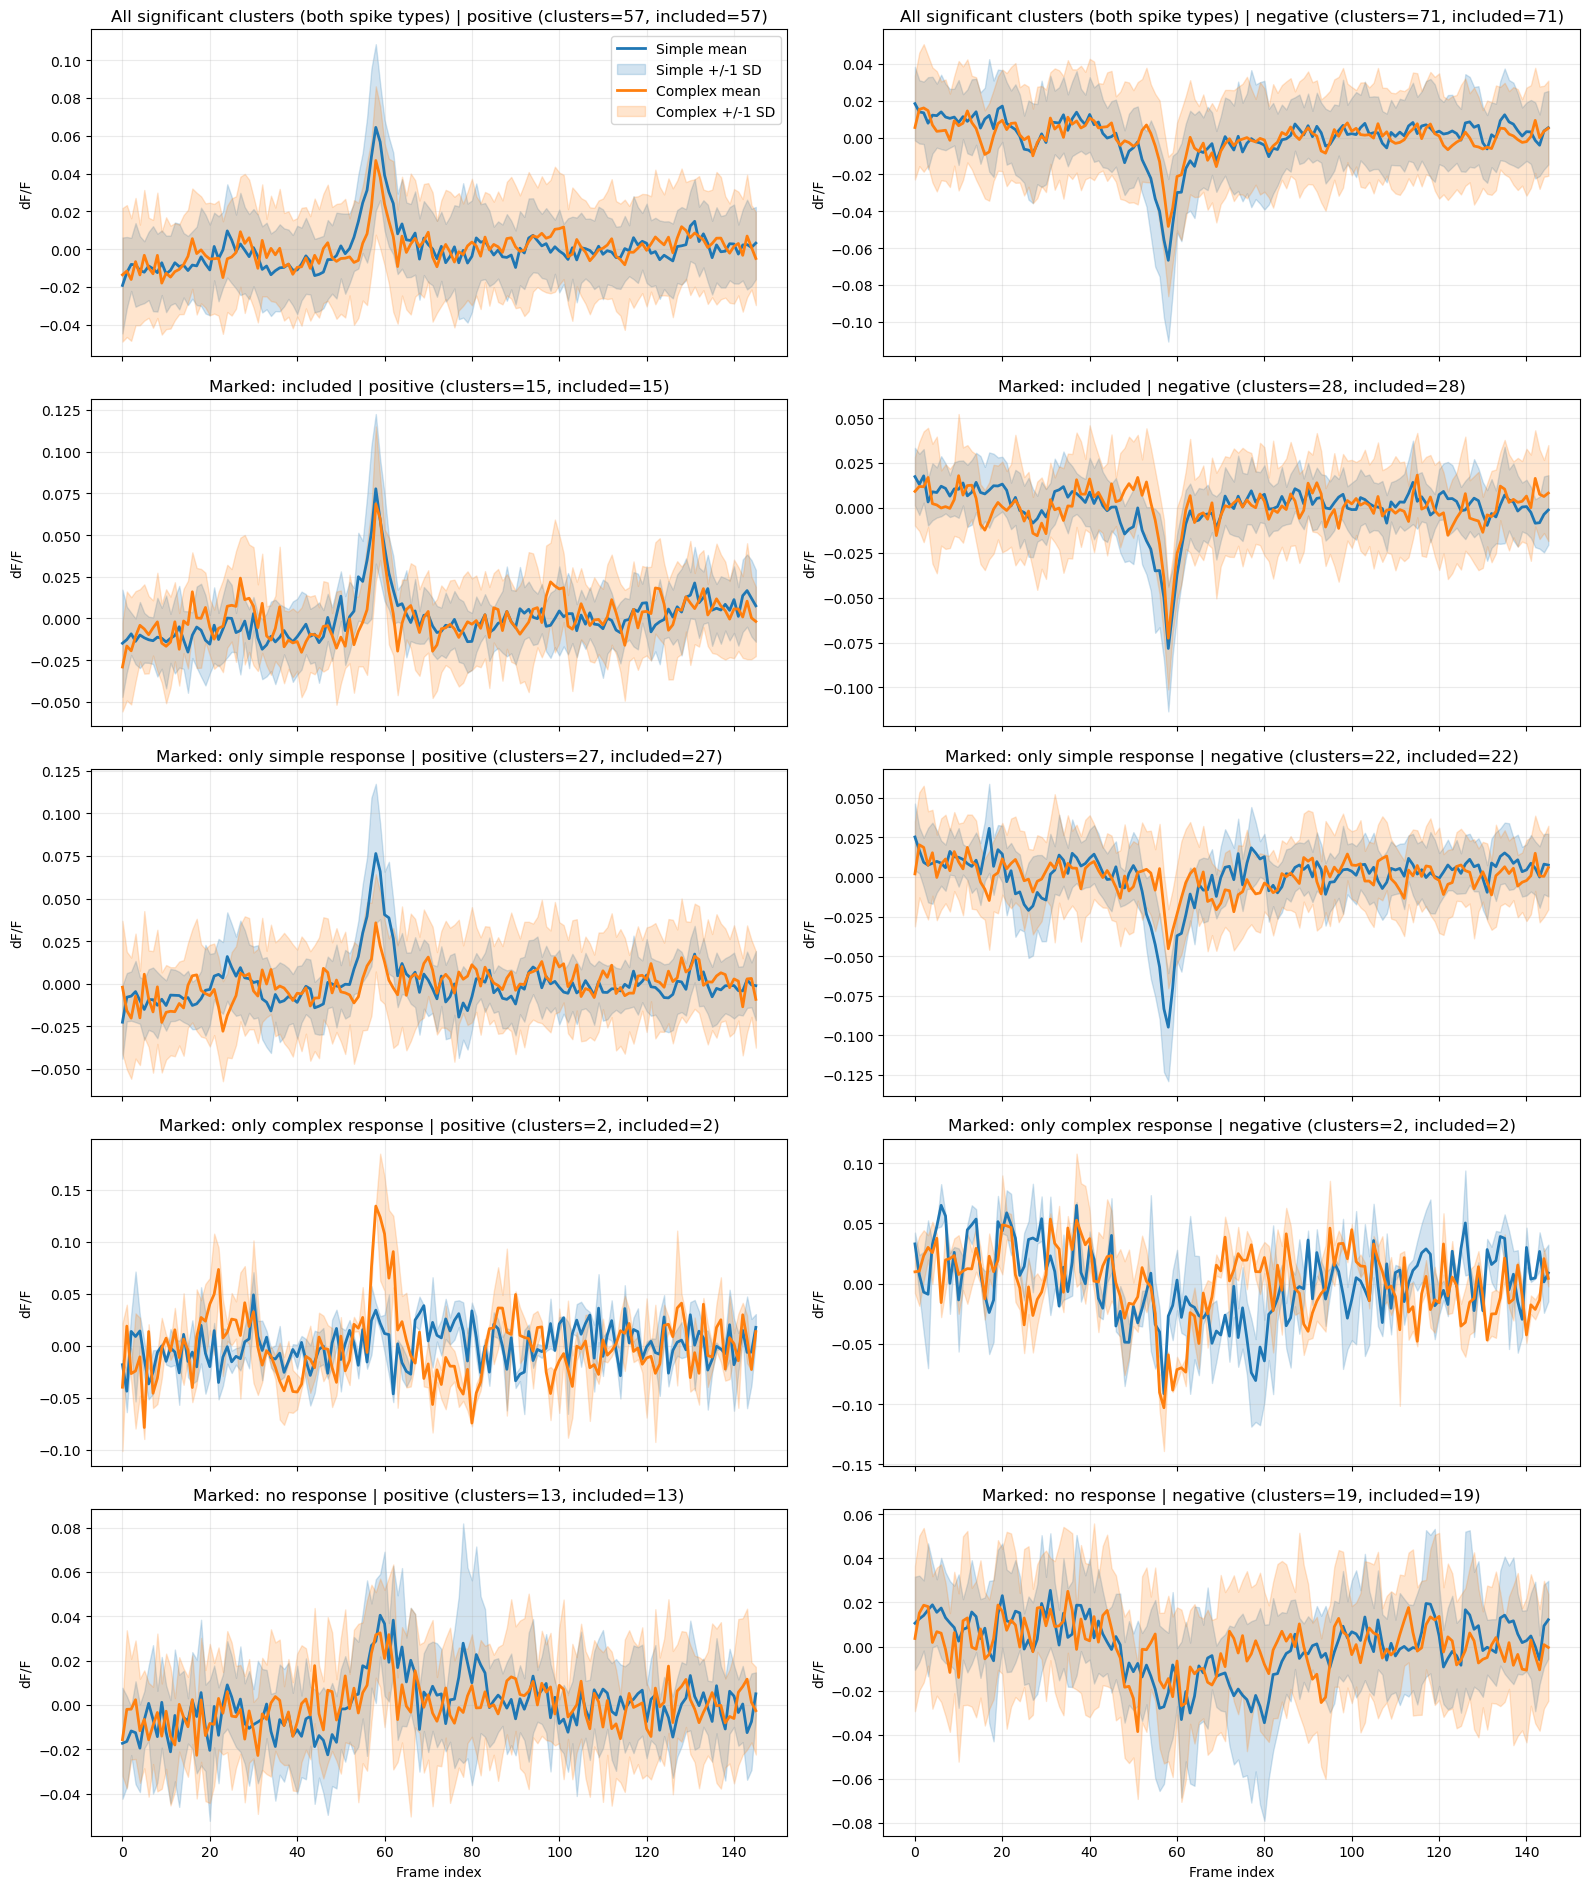

In [6]:
def _plot_mean_std(ax, df, title):
    if df.empty:
        ax.set_title(f"{title} (clusters=0, included=0)")
        ax.text(0.5, 0.5, "No clusters", ha="center", va="center", transform=ax.transAxes)
        ax.grid(alpha=0.2)
        return

    simple_list = [np.asarray(x, dtype=float) for x in df["simple_mean_trace"].tolist()]
    complex_list = [np.asarray(x, dtype=float) for x in df["complex_mean_trace"].tolist()]

    simple_list = [x - np.nanmean(x) for x in simple_list]
    complex_list = [x - np.nanmean(x) for x in complex_list]

    lengths = [len(x) for x in simple_list if len(x) > 0]
    if not lengths:
        ax.set_title(f"{title} (clusters={len(df)}, included=0)")
        ax.text(0.5, 0.5, "No valid traces", ha="center", va="center", transform=ax.transAxes)
        ax.grid(alpha=0.2)
        return

    target_len = max(set(lengths), key=lengths.count)
    valid_idx = [
        i for i, (s, c) in enumerate(zip(simple_list, complex_list))
        if len(s) == target_len and len(c) == target_len
    ]

    if not valid_idx:
        ax.set_title(f"{title} (clusters={len(df)}, included=0)")
        ax.text(0.5, 0.5, "No aligned traces", ha="center", va="center", transform=ax.transAxes)
        ax.grid(alpha=0.2)
        return

    simple_mat = np.vstack([simple_list[i] for i in valid_idx])
    complex_mat = np.vstack([complex_list[i] for i in valid_idx])

    x = np.arange(target_len)
    simple_mean = np.nanmean(simple_mat, axis=0)
    simple_std = np.nanstd(simple_mat, axis=0)
    complex_mean = np.nanmean(complex_mat, axis=0)
    complex_std = np.nanstd(complex_mat, axis=0)

    ax.plot(x, simple_mean, label="Simple mean", color="tab:blue", linewidth=2)
    ax.fill_between(
        x,
        simple_mean - simple_std,
        simple_mean + simple_std,
        color="tab:blue",
        alpha=0.2,
        label="Simple +/-1 SD",
    )
    ax.plot(x, complex_mean, label="Complex mean", color="tab:orange", linewidth=2)
    ax.fill_between(
        x,
        complex_mean - complex_std,
        complex_mean + complex_std,
        color="tab:orange",
        alpha=0.2,
        label="Complex +/-1 SD",
    )
    ax.set_title(f"{title} (clusters={len(df)}, included={len(valid_idx)})")
    ax.set_ylabel("dF/F")
    ax.grid(alpha=0.25)

def _is_positive(v):
    s = str(v).strip().lower()
    if s in {"1", "+1", "pos", "positive", "+"}:
        return True
    if s in {"-1", "neg", "negative", "-"}:
        return False
    return "neg" not in s

sig_both = significant_clusters_both_spikes.copy()
sig_both["disqualify_reason"] = sig_both["disqualify_reason"].fillna("")

groups = [
    ("All significant clusters (both spike types)", sig_both),
    ("Marked: included", sig_both[sig_both["disqualify_reason"] == ""]),
    ("Marked: only simple response", sig_both[sig_both["disqualify_reason"] == "only_simple_response"]),
    ("Marked: only complex response", sig_both[sig_both["disqualify_reason"] == "only_complex_response"]),
    ("Marked: no response", sig_both[sig_both["disqualify_reason"] == "no_response"]),
]

fig, axes = plt.subplots(len(groups), 2, figsize=(16, 3.8 * len(groups)), sharex=True)
for row_idx, (group_title, gdf) in enumerate(groups):
    pos_mask = gdf["sign"].map(_is_positive)
    pos_df = gdf[pos_mask]
    neg_df = gdf[~pos_mask]
    _plot_mean_std(axes[row_idx, 0], pos_df, f"{group_title} | positive")
    _plot_mean_std(axes[row_idx, 1], neg_df, f"{group_title} | negative")

axes[-1, 0].set_xlabel("Frame index")
axes[-1, 1].set_xlabel("Frame index")
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    axes[0, 0].legend(loc="upper right")
plt.tight_layout()
plt.show()


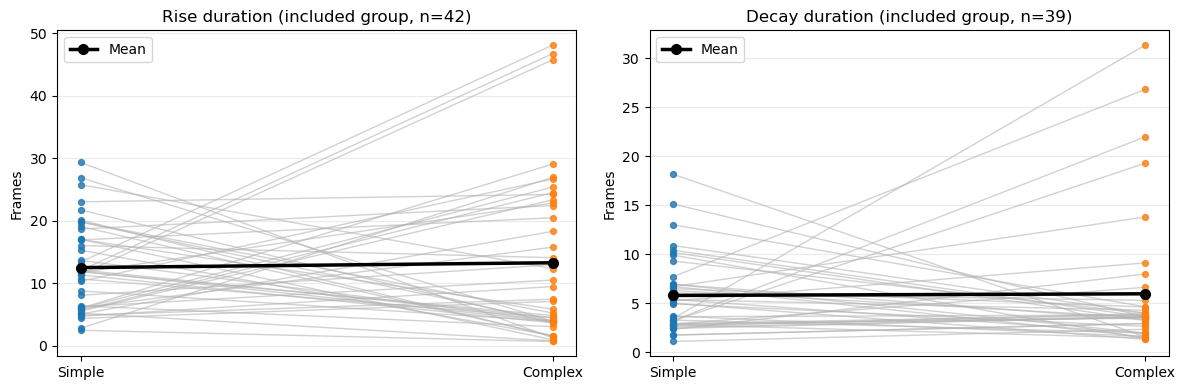

Included clusters (all): 43
Rise duration paired n: 42 | simple mean=12.53 | complex mean=13.30
Decay duration paired n: 39 | simple mean=5.78 | complex mean=5.94


In [7]:
# Included group: paired lines per cluster (simple -> complex) for rise/decay durations
# Definitions used here:
#   rise_duration  = peak_time - t10_rise
#   decay_duration = t10_decay - peak_time
included_df = significant_clusters_both_spikes.copy()
included_df["disqualify_reason"] = included_df["disqualify_reason"].fillna("")
included_df = included_df[included_df["disqualify_reason"] == ""].copy()

def _to_num(s):
    return pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)

# Build per-cluster durations from saved kinetics timestamps
tmp = included_df.copy()
tmp["simple_peak_time"] = _to_num(tmp["simple_peak_index"])
tmp["complex_peak_time"] = _to_num(tmp["complex_peak_index"])
tmp["simple_t10_rise"] = _to_num(tmp["simple_t10_rise"])
tmp["complex_t10_rise"] = _to_num(tmp["complex_t10_rise"])
tmp["simple_t10_decay"] = _to_num(tmp["simple_t10_decay"])
tmp["complex_t10_decay"] = _to_num(tmp["complex_t10_decay"])

tmp["simple_rise_duration"] = tmp["simple_peak_time"] - tmp["simple_t10_rise"]
tmp["complex_rise_duration"] = tmp["complex_peak_time"] - tmp["complex_t10_rise"]
tmp["simple_decay_duration"] = tmp["simple_t10_decay"] - tmp["simple_peak_time"]
tmp["complex_decay_duration"] = tmp["complex_t10_decay"] - tmp["complex_peak_time"]

def _paired_metric(df, simple_col, complex_col):
    out = df[[simple_col, complex_col]].copy().dropna()
    # keep only non-negative durations
    out = out[(out[simple_col] >= 0) & (out[complex_col] >= 0)]
    return out[simple_col].to_numpy(dtype=float), out[complex_col].to_numpy(dtype=float)

rise_s, rise_c = _paired_metric(tmp, "simple_rise_duration", "complex_rise_duration")
decay_s, decay_c = _paired_metric(tmp, "simple_decay_duration", "complex_decay_duration")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, (name, svals, cvals) in zip(axes, [("Rise", rise_s, rise_c), ("Decay", decay_s, decay_c)]):
    x0, x1 = 0, 1
    for s, c in zip(svals, cvals):
        ax.plot([x0, x1], [s, c], color="0.7", linewidth=1, alpha=0.6, zorder=1)

    if len(svals) > 0:
        ax.scatter(np.full(len(svals), x0), svals, color="tab:blue", s=18, alpha=0.8, zorder=2)
        ax.scatter(np.full(len(cvals), x1), cvals, color="tab:orange", s=18, alpha=0.8, zorder=2)
        s_mean = np.nanmean(svals)
        c_mean = np.nanmean(cvals)
        ax.plot([x0, x1], [s_mean, c_mean], color="black", linewidth=2.5, marker="o", markersize=7, zorder=3, label="Mean")

    ax.set_xticks([x0, x1])
    ax.set_xticklabels(["Simple", "Complex"])
    ax.set_title(f"{name} duration (included group, n={len(svals)})")
    ax.set_ylabel("Frames")
    ax.grid(axis="y", alpha=0.25)
    if len(svals) > 0:
        ax.legend(loc="best")

plt.tight_layout()
plt.show()

print(f"Included clusters (all): {len(included_df)}")
print(f"Rise duration paired n: {len(rise_s)} | simple mean={np.nanmean(rise_s) if len(rise_s)>0 else np.nan:.2f} | complex mean={np.nanmean(rise_c) if len(rise_c)>0 else np.nan:.2f}")
print(f"Decay duration paired n: {len(decay_s)} | simple mean={np.nanmean(decay_s) if len(decay_s)>0 else np.nan:.2f} | complex mean={np.nanmean(decay_c) if len(decay_c)>0 else np.nan:.2f}")


# Analyze kinetics V2


In [30]:
kinetics_v2_dataset_path = sta_dir / "cluster_dataset_with_kinetics_v2.pkl"
kinetics_df_v2_analysis = pd.read_pickle(kinetics_v2_dataset_path)

neuron_spike_flags_v2 = (
    kinetics_df_v2_analysis.assign(
        has_simple=kinetics_df_v2_analysis["simple_peak_frames"].map(lambda peaks: len(peaks) > 0),
        has_complex=kinetics_df_v2_analysis["complex_peak_frames"].map(lambda peaks: len(peaks) > 0),
    )
    .groupby(neuron_key_cols, dropna=False, as_index=False)[["has_simple", "has_complex"]]
    .any()
)

neurons_with_both_spikes_v2 = neuron_spike_flags_v2.loc[
    neuron_spike_flags_v2["has_simple"] & neuron_spike_flags_v2["has_complex"], neuron_key_cols
]

significant_clusters_both_spikes_v2 = (
    kinetics_df_v2_analysis.loc[kinetics_df_v2_analysis["is_significant"].astype(bool)]
    .merge(neurons_with_both_spikes_v2, on=neuron_key_cols, how="inner")
    .copy()
)

print(f"Loaded V2 dataset: {kinetics_v2_dataset_path}")
print(f"Neurons with both simple and complex spikes: {len(neurons_with_both_spikes_v2)}/{len(neuron_df)}")
print(f"Significant clusters from those neurons: {len(significant_clusters_both_spikes_v2)}/{len(kinetics_df_v2_analysis)}")


Loaded V2 dataset: Z:\Adam-Lab-Shared\Data\Miki_Meerson\Imaging\HYP-JEDI\Hyp3\L\02-02-2026-awake\FOV1\z-18-x2\sta_analysis\cluster_dataset_with_kinetics_v2.pkl
Neurons with both simple and complex spikes: 81/87
Significant clusters from those neurons: 128/10475


In [31]:
display(significant_clusters_both_spikes_v2)

,cage,mouse_name,recording_date,behavior,recording_name,neuron_id,cluster_id,sign,is_significant,p_value,...,complex_peak_frames,disqualify_reason,disqualify_kinetics,simple_tau_rise,simple_tau_decay,complex_tau_rise,complex_tau_decay,simple_peak_index,complex_peak_index,kinetics_error
0,Hyp3,L,02-02-2026,awake,z-18-x2,0,1,negative,True,0.039801,...,"[3074, 4119, 4704, 5473, 5975, 6906, 7252, 8205]",peak_misaligned,True,NaN,NaN,NaN,NaN,NaN,NaN,peak_misaligned
1,Hyp3,L,02-02-2026,awake,z-18-x2,3,1,negative,True,0.009950,...,"[1536, 3601, 8537]",,False,3.392311,0.921144,0.874796,1.659521,0.0,0.0,
2,Hyp3,L,02-02-2026,awake,z-18-x2,3,2,negative,True,0.079602,...,"[1536, 3601, 8537]",,False,1.582417,1.243613,2.719314,2.531761,0.0,1.0,
3,Hyp3,L,02-02-2026,awake,z-18-x2,4,1,negative,True,0.004975,...,"[637, 1075, 2105, 2390, 4877, 5932, 8398]",peak_misaligned,True,NaN,NaN,NaN,NaN,NaN,NaN,peak_misaligned
4,Hyp3,L,02-02-2026,awake,z-18-x2,4,2,positive,True,0.004975,...,"[637, 1075, 2105, 2390, 4877, 5932, 8398]",,False,1.763569,8.113332,1.250960,1.267979,0.0,1.0,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,Hyp3,L,02-02-2026,awake,z-18-x2,84,2,negative,True,0.004975,...,"[555, 2140, 7521]",peak_misaligned,True,NaN,NaN,NaN,NaN,NaN,NaN,peak_misaligned
124,Hyp3,L,02-02-2026,awake,z-18-x2,84,3,negative,True,0.004975,...,"[555, 2140, 7521]",peak_misaligned,True,NaN,NaN,NaN,NaN,NaN,NaN,peak_misaligned
125,Hyp3,L,02-02-2026,awake,z-18-x2,84,4,negative,True,0.009950,...,"[555, 2140, 7521]",peak_misaligned,True,NaN,NaN,NaN,NaN,NaN,NaN,peak_misaligned
126,Hyp3,L,02-02-2026,awake,z-18-x2,84,5,negative,True,0.039801,...,"[555, 2140, 7521]",peak_misaligned,True,NaN,NaN,NaN,NaN,NaN,NaN,peak_misaligned


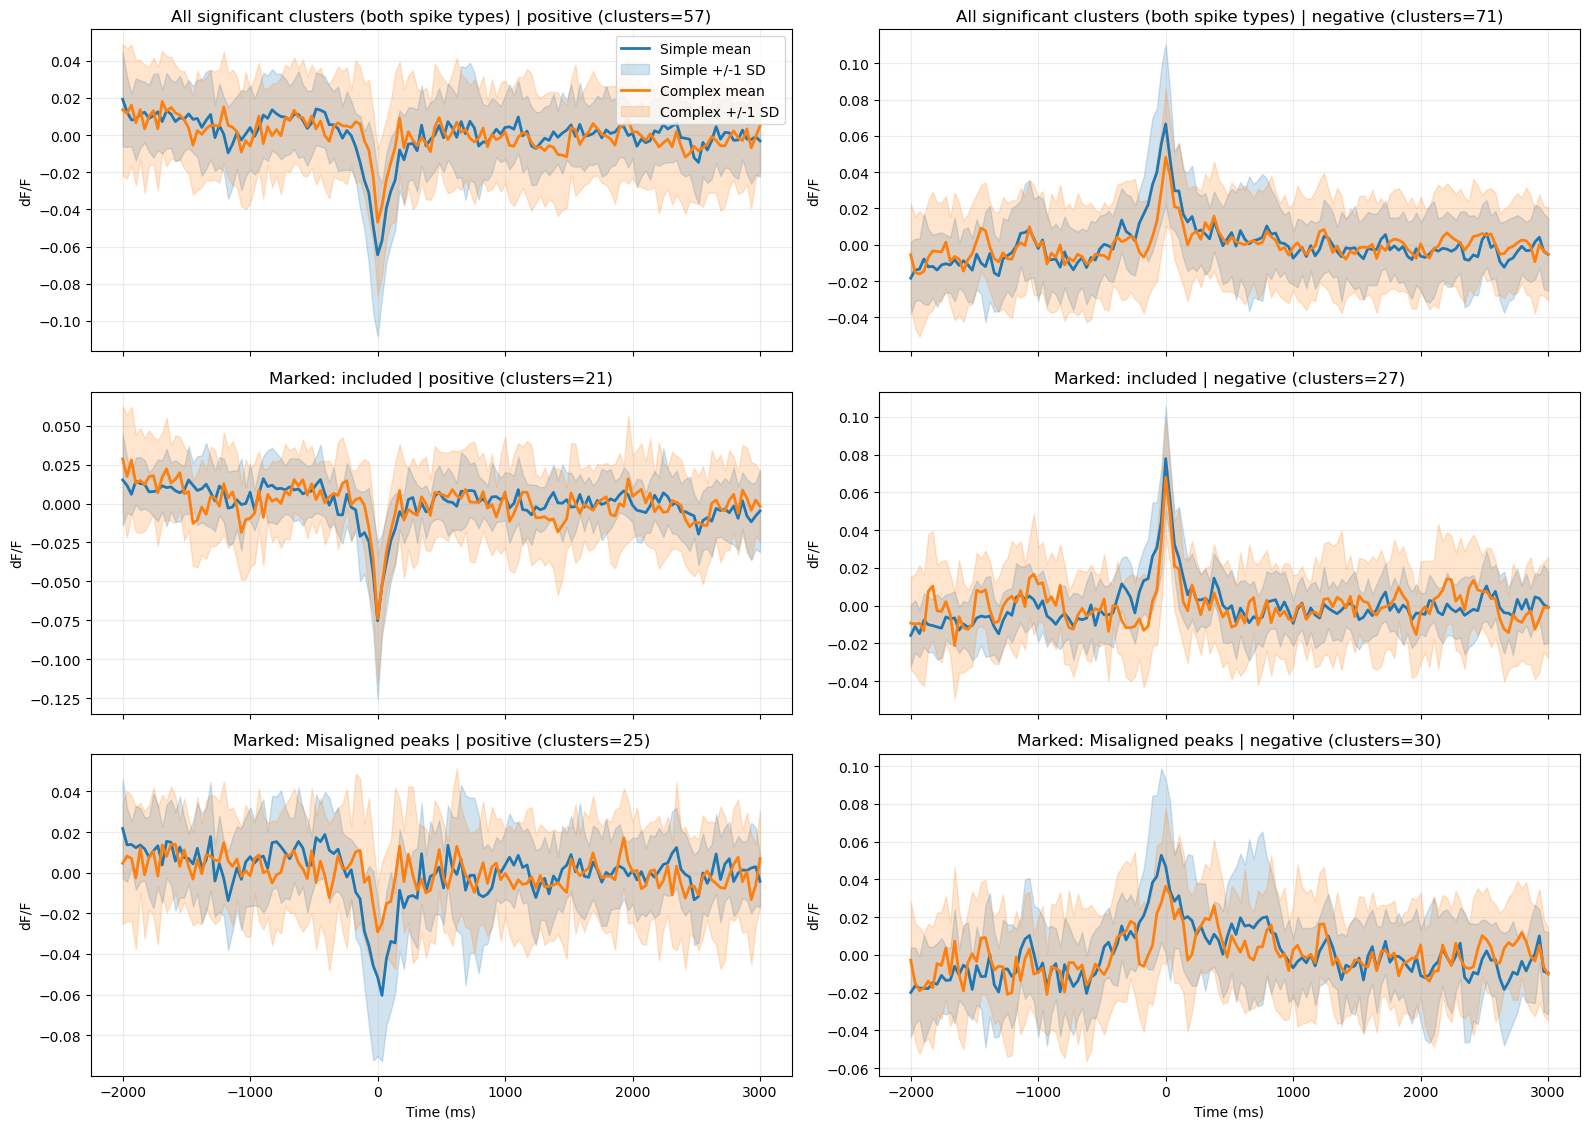

In [32]:
ms_per_frame_v2 = 1000.0 / float(fps)

def _plot_mean_std_v2(ax, df, title):
    simple_list = [np.asarray(x, dtype=float) for x in df["simple_mean_trace"].tolist()]
    complex_list = [np.asarray(x, dtype=float) for x in df["complex_mean_trace"].tolist()]

    simple_list = [x - np.nanmean(x) for x in simple_list]
    complex_list = [x - np.nanmean(x) for x in complex_list]

    lengths = [len(x) for x in simple_list if len(x) > 0]
    if not lengths:
        ax.set_title(f"{title} (clusters={len(df)})")
        ax.text(0.5, 0.5, "No valid traces", ha="center", va="center", transform=ax.transAxes)
        ax.grid(alpha=0.2)
        return

    target_len = max(set(lengths), key=lengths.count)
    valid_idx = [
        i for i, (s, c) in enumerate(zip(simple_list, complex_list))
        if len(s) == target_len and len(c) == target_len
    ]

    if not valid_idx:
        ax.set_title(f"{title} (clusters={len(df)})")
        ax.text(0.5, 0.5, "No aligned traces", ha="center", va="center", transform=ax.transAxes)
        ax.grid(alpha=0.2)
        return

    simple_mat = np.vstack([simple_list[i] for i in valid_idx])
    complex_mat = np.vstack([complex_list[i] for i in valid_idx])

    # Anchor 0 ms to the true event index when available (prefer rel_frames/pre_frames globals).
    if "rel_frames" in globals() and np.asarray(rel_frames).size == target_len:
        x_ms = np.asarray(rel_frames, dtype=float) * ms_per_frame_v2
    else:
        if "pre_frames" in globals() and int(pre_frames) < target_len:
            zero_idx = int(pre_frames)
        else:
            zero_idx = target_len // 2
        x_ms = (np.arange(target_len, dtype=float) - zero_idx) * ms_per_frame_v2
    simple_mean = np.nanmean(simple_mat, axis=0)
    simple_std = np.nanstd(simple_mat, axis=0)
    complex_mean = np.nanmean(complex_mat, axis=0)
    complex_std = np.nanstd(complex_mat, axis=0)

    ax.plot(x_ms, simple_mean, label="Simple mean", color="tab:blue", linewidth=2)
    ax.fill_between(x_ms, simple_mean - simple_std, simple_mean + simple_std, color="tab:blue", alpha=0.2, label="Simple +/-1 SD")
    ax.plot(x_ms, complex_mean, label="Complex mean", color="tab:orange", linewidth=2)
    ax.fill_between(x_ms, complex_mean - complex_std, complex_mean + complex_std, color="tab:orange", alpha=0.2, label="Complex +/-1 SD")
    ax.set_title(f"{title} (clusters={len(df)})")
    ax.set_ylabel("dF/F")
    ax.grid(alpha=0.25)

def _is_positive_v2(v):
    s = str(v).strip().lower()
    if s in {"1", "+1", "pos", "positive", "+"}:
        return True
    if s in {"-1", "neg", "negative", "-"}:
        return False
    return "neg" not in s

sig_both_v2 = significant_clusters_both_spikes_v2.copy()
sig_both_v2["disqualify_reason"] = sig_both_v2["disqualify_reason"].fillna("")

groups_v2 = [
    ("All significant clusters (both spike types)", sig_both_v2),
    ("Marked: included", sig_both_v2[sig_both_v2["disqualify_reason"] == ""]),
    ("Marked: Misaligned peaks", sig_both_v2[sig_both_v2["disqualify_reason"] == "peak_misaligned"]),
]

fig, axes = plt.subplots(len(groups_v2), 2, figsize=(16, 3.8 * len(groups_v2)), sharex=True)
for row_idx, (group_title, gdf) in enumerate(groups_v2):
    pos_mask = gdf["sign"].map(_is_positive_v2)
    pos_df = gdf[pos_mask]
    neg_df = gdf[~pos_mask]
    _plot_mean_std_v2(axes[row_idx, 0], pos_df, f"{group_title} | positive")
    _plot_mean_std_v2(axes[row_idx, 1], neg_df, f"{group_title} | negative")

axes[-1, 0].set_xlabel("Time (ms)")
axes[-1, 1].set_xlabel("Time (ms)")
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    axes[0, 0].legend(loc="upper right")
plt.tight_layout()
plt.show()


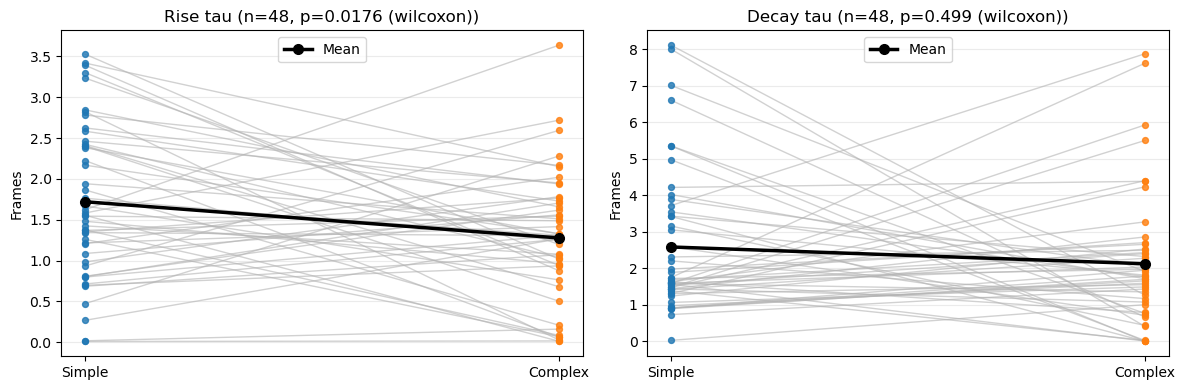

Included clusters (all): 48
Rise tau paired n: 48 | simple mean=1.72 | complex mean=1.28 | p=0.0176 (wilcoxon)
Decay tau paired n: 48 | simple mean=2.59 | complex mean=2.13 | p=0.499 (wilcoxon)


In [33]:
# Included group: paired lines for V2 taus (simple -> complex)
from scipy.stats import wilcoxon, ttest_rel

included_v2 = significant_clusters_both_spikes_v2.copy()
included_v2["disqualify_reason"] = included_v2["disqualify_reason"].fillna("")
included_v2 = included_v2[included_v2["disqualify_reason"] == ""].copy()

def _paired_tau(df, simple_col, complex_col):
    out = df[[simple_col, complex_col]].copy()
    out[simple_col] = pd.to_numeric(out[simple_col], errors="coerce")
    out[complex_col] = pd.to_numeric(out[complex_col], errors="coerce")
    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    out = out[(out[simple_col] >= 0) & (out[complex_col] >= 0)]
    return out[simple_col].to_numpy(dtype=float), out[complex_col].to_numpy(dtype=float)

def _paired_pvalue(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) < 2:
        return np.nan, "n<2"
    try:
        p = wilcoxon(a, b, alternative="two-sided", zero_method="wilcox").pvalue
        return float(p), "wilcoxon"
    except Exception:
        try:
            p = ttest_rel(a, b, nan_policy="omit").pvalue
            return float(p), "ttest_rel"
        except Exception:
            return np.nan, "failed"

rise_s_v2, rise_c_v2 = _paired_tau(included_v2, "simple_tau_rise", "complex_tau_rise")
decay_s_v2, decay_c_v2 = _paired_tau(included_v2, "simple_tau_decay", "complex_tau_decay")
p_rise, p_rise_method = _paired_pvalue(rise_s_v2, rise_c_v2)
p_decay, p_decay_method = _paired_pvalue(decay_s_v2, decay_c_v2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, (name, svals, cvals, pval, pmeth) in zip(
    axes,
    [
        ("Rise tau", rise_s_v2, rise_c_v2, p_rise, p_rise_method),
        ("Decay tau", decay_s_v2, decay_c_v2, p_decay, p_decay_method),
    ],
):
    x0, x1 = 0, 1
    for s, c in zip(svals, cvals):
        ax.plot([x0, x1], [s, c], color="0.7", linewidth=1, alpha=0.6, zorder=1)

    if len(svals) > 0:
        ax.scatter(np.full(len(svals), x0), svals, color="tab:blue", s=18, alpha=0.8, zorder=2)
        ax.scatter(np.full(len(cvals), x1), cvals, color="tab:orange", s=18, alpha=0.8, zorder=2)
        s_mean = np.nanmean(svals)
        c_mean = np.nanmean(cvals)
        ax.plot([x0, x1], [s_mean, c_mean], color="black", linewidth=2.5, marker="o", markersize=7, zorder=3, label="Mean")

    p_txt = f"p={pval:.3g} ({pmeth})" if np.isfinite(pval) else f"p=NA ({pmeth})"
    ax.set_xticks([x0, x1])
    ax.set_xticklabels(["Simple", "Complex"])
    ax.set_title(f"{name} (n={len(svals)}, {p_txt})")
    ax.set_ylabel("Frames")
    ax.grid(axis="y", alpha=0.25)
    if len(svals) > 0:
        ax.legend(loc="best")

plt.tight_layout()
plt.show()

print(f"Included clusters (all): {len(included_v2)}")
print(f"Rise tau paired n: {len(rise_s_v2)} | simple mean={np.nanmean(rise_s_v2) if len(rise_s_v2)>0 else np.nan:.2f} | complex mean={np.nanmean(rise_c_v2) if len(rise_c_v2)>0 else np.nan:.2f} | p={p_rise:.3g} ({p_rise_method})")
print(f"Decay tau paired n: {len(decay_s_v2)} | simple mean={np.nanmean(decay_s_v2) if len(decay_s_v2)>0 else np.nan:.2f} | complex mean={np.nanmean(decay_c_v2) if len(decay_c_v2)>0 else np.nan:.2f} | p={p_decay:.3g} ({p_decay_method})")


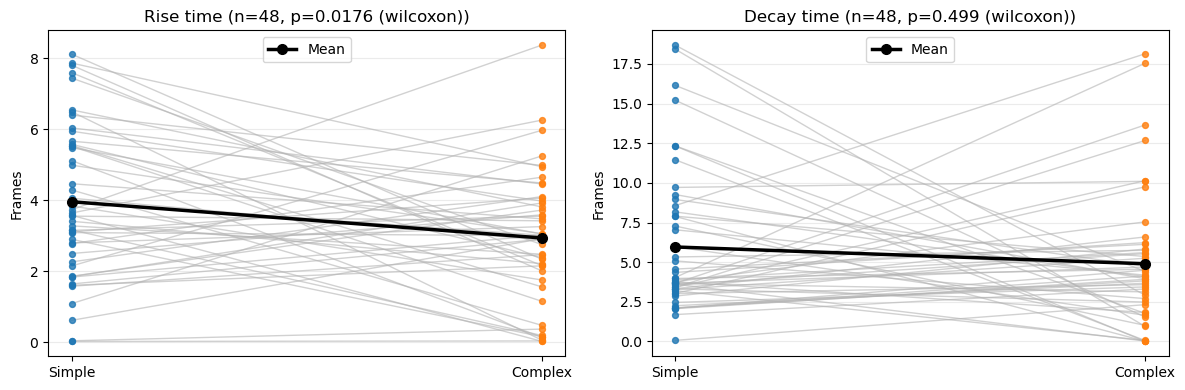

clusters (all): 48
Rise time n: 48 | simple mean=3.96 | complex mean=2.94 | p=0.0176 (wilcoxon)
Decay time n: 48 | simple mean=5.96 | complex mean=4.90 | p=0.499 (wilcoxon)


In [34]:
# Included V2: compare start->peak rise time and peak->end decay time (simple vs complex)
# We estimate boundaries from tau using a fraction of amplitude (default 10%).
from scipy.stats import wilcoxon, ttest_rel

frac = 0.1
k = -np.log(frac)  # duration multiplier from tau

included_v2_sp = significant_clusters_both_spikes_v2.copy()
included_v2_sp["disqualify_reason"] = included_v2_sp["disqualify_reason"].fillna("")
included_v2_sp = included_v2_sp[included_v2_sp["disqualify_reason"] == ""].copy()

def _clean_pair(df, s_col, c_col):
    out = df[[s_col, c_col]].copy()
    out[s_col] = pd.to_numeric(out[s_col], errors="coerce")
    out[c_col] = pd.to_numeric(out[c_col], errors="coerce")
    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    out = out[(out[s_col] >= 0) & (out[c_col] >= 0)]
    return out[s_col].to_numpy(dtype=float), out[c_col].to_numpy(dtype=float)

def _paired_pvalue(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) < 2:
        return np.nan, "n<2"
    try:
        p = wilcoxon(a, b, alternative="two-sided", zero_method="wilcox").pvalue
        return float(p), "wilcoxon"
    except Exception:
        try:
            p = ttest_rel(a, b, nan_policy="omit").pvalue
            return float(p), "ttest_rel"
        except Exception:
            return np.nan, "failed"

# Duration from estimated start to peak and peak to estimated end
included_v2_sp["simple_rise_start_to_peak"] = k * pd.to_numeric(included_v2_sp["simple_tau_rise"], errors="coerce")
included_v2_sp["complex_rise_start_to_peak"] = k * pd.to_numeric(included_v2_sp["complex_tau_rise"], errors="coerce")
included_v2_sp["simple_decay_peak_to_end"] = k * pd.to_numeric(included_v2_sp["simple_tau_decay"], errors="coerce")
included_v2_sp["complex_decay_peak_to_end"] = k * pd.to_numeric(included_v2_sp["complex_tau_decay"], errors="coerce")

rise_s2p_s, rise_s2p_c = _clean_pair(included_v2_sp, "simple_rise_start_to_peak", "complex_rise_start_to_peak")
decay_p2e_s, decay_p2e_c = _clean_pair(included_v2_sp, "simple_decay_peak_to_end", "complex_decay_peak_to_end")
p_rise2, p_rise2_method = _paired_pvalue(rise_s2p_s, rise_s2p_c)
p_decay2, p_decay2_method = _paired_pvalue(decay_p2e_s, decay_p2e_c)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, (name, svals, cvals, pval, pmeth) in zip(
    axes,
    [
        ("Rise time", rise_s2p_s, rise_s2p_c, p_rise2, p_rise2_method),
        ("Decay time", decay_p2e_s, decay_p2e_c, p_decay2, p_decay2_method),
    ],
):
    x0, x1 = 0, 1
    for s, c in zip(svals, cvals):
        ax.plot([x0, x1], [s, c], color="0.7", linewidth=1, alpha=0.6, zorder=1)

    if len(svals) > 0:
        ax.scatter(np.full(len(svals), x0), svals, color="tab:blue", s=18, alpha=0.8, zorder=2)
        ax.scatter(np.full(len(cvals), x1), cvals, color="tab:orange", s=18, alpha=0.8, zorder=2)
        s_mean = np.nanmean(svals)
        c_mean = np.nanmean(cvals)
        ax.plot([x0, x1], [s_mean, c_mean], color="black", linewidth=2.5, marker="o", markersize=7, zorder=3, label="Mean")

    p_txt = f"p={pval:.3g} ({pmeth})" if np.isfinite(pval) else f"p=NA ({pmeth})"
    ax.set_xticks([x0, x1])
    ax.set_xticklabels(["Simple", "Complex"])
    ax.set_title(f"{name} (n={len(svals)}, {p_txt})")
    ax.set_ylabel("Frames")
    ax.grid(axis="y", alpha=0.25)
    if len(svals) > 0:
        ax.legend(loc="best")

plt.tight_layout()
plt.show()

print(f"clusters (all): {len(included_v2_sp)}")
print(f"Rise time n: {len(rise_s2p_s)} | simple mean={np.nanmean(rise_s2p_s) if len(rise_s2p_s)>0 else np.nan:.2f} | complex mean={np.nanmean(rise_s2p_c) if len(rise_s2p_c)>0 else np.nan:.2f} | p={p_rise2:.3g} ({p_rise2_method})")
print(f"Decay time n: {len(decay_p2e_s)} | simple mean={np.nanmean(decay_p2e_s) if len(decay_p2e_s)>0 else np.nan:.2f} | complex mean={np.nanmean(decay_p2e_c) if len(decay_p2e_c)>0 else np.nan:.2f} | p={p_decay2:.3g} ({p_decay2_method})")


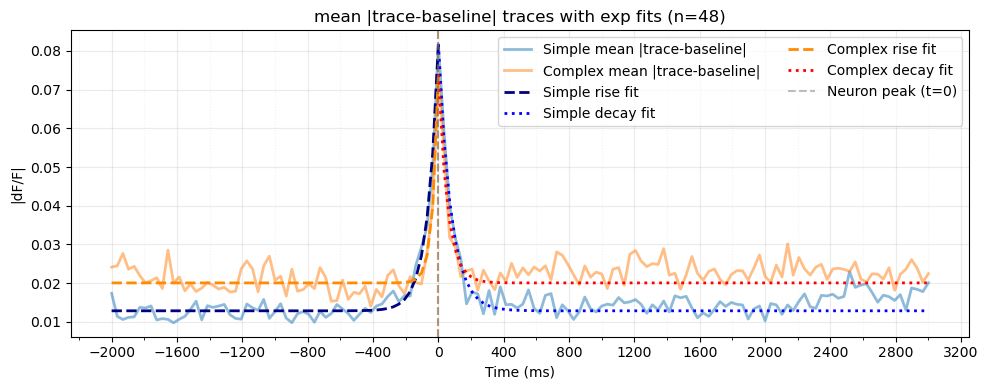

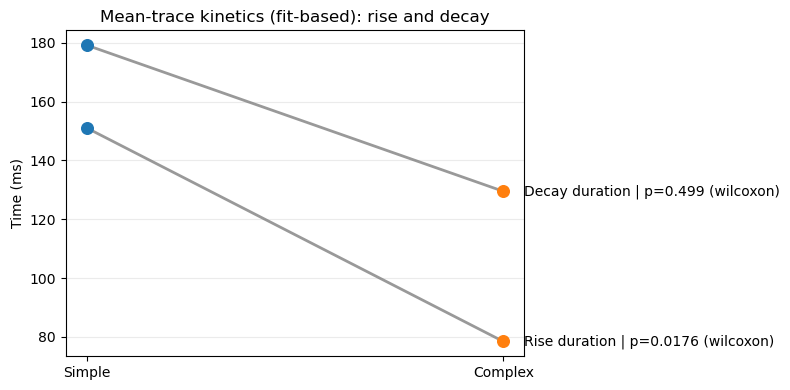

Included clusters used for aligned mean traces: 48
Simple:  peak_ms=0.00, tau_r_ms=65.611, tau_d_ms=77.844, rise_dur_ms=151.07, decay_dur_ms=179.24
Complex: peak_ms=0.00, tau_r_ms=34.058, tau_d_ms=56.245, rise_dur_ms=78.42, decay_dur_ms=129.51
Rise duration p-value: 0.0176 (wilcoxon), n=48
Decay duration p-value: 0.499 (wilcoxon), n=48


In [38]:
# V2: mean(abs(trace)) kinetics for included group using exponential fit
ms_per_frame_v2 = 1000.0 / float(fps)

included_v2_mean = significant_clusters_both_spikes_v2.copy()
included_v2_mean["disqualify_reason"] = included_v2_mean["disqualify_reason"].fillna("")
included_v2_mean = included_v2_mean[included_v2_mean["disqualify_reason"] == ""].copy()

if included_v2_mean.empty:
    raise RuntimeError("No included clusters found in V2 dataset.")

# Build aligned sets by most common rel_frames signature
rel_sig = []
simple_abs = []
complex_abs = []
for _, row in included_v2_mean.iterrows():
    s = np.asarray(row["simple_mean_trace"], dtype=float)
    c = np.asarray(row["complex_mean_trace"], dtype=float)
    rf = np.asarray(get_rel_frames(int(row["neuron_id"]), sta_dir), dtype=int)
    if len(s) == 0 or len(c) == 0 or len(rf) == 0:
        continue
    n = min(len(s), len(c), len(rf))
    s = s[:n]
    c = c[:n]
    rf = rf[:n]

    # Baseline-center each trace from pre-0 frames, then take abs to combine pos/neg responses.
    pre_mask = rf < 0
    s_base = float(np.nanmedian(s[pre_mask])) if np.any(pre_mask) else float(np.nanmedian(s))
    c_base = float(np.nanmedian(c[pre_mask])) if np.any(pre_mask) else float(np.nanmedian(c))
    s = np.abs(s - s_base)
    c = np.abs(c - c_base)

    rel_sig.append(tuple(rf.tolist()))
    simple_abs.append(s)
    complex_abs.append(c)

if len(simple_abs) == 0:
    raise RuntimeError("No valid traces after preprocessing.")

from collections import Counter
sig_mode, _ = Counter(rel_sig).most_common(1)[0]
keep_idx = [i for i, sig in enumerate(rel_sig) if sig == sig_mode]

rel_frames_mean = np.asarray(sig_mode, dtype=int)
rel_time_ms = rel_frames_mean.astype(float) * ms_per_frame_v2
simple_mat = np.vstack([simple_abs[i] for i in keep_idx])
complex_mat = np.vstack([complex_abs[i] for i in keep_idx])

simple_mean = np.nanmean(simple_mat, axis=0)
simple_std = np.nanstd(simple_mat, axis=0)
complex_mean = np.nanmean(complex_mat, axis=0)
complex_std = np.nanstd(complex_mat, axis=0)

# Robust peak finder: avoid boundary peaks so fit has points on both sides
def _safe_peak_idx(y, min_side=4):
    y = np.asarray(y, dtype=float)
    if len(y) < (2 * min_side + 1):
        raise ValueError(f"Trace too short for min_side={min_side}: len={len(y)}")
    mid = np.abs(y[min_side:len(y)-min_side])
    local = int(np.nanargmax(mid))
    return local + min_side

peak_simple = _safe_peak_idx(simple_mean, min_side=4)
peak_complex = _safe_peak_idx(complex_mean, min_side=4)

fit_half = max(4, int(fps // 2))
ks_mean = fit_exp_rise_decay(rel_time_ms, simple_mean, peak_simple)
kc_mean = fit_exp_rise_decay(rel_time_ms, complex_mean, peak_complex)

# Durations from tau (10% boundary assumption)
frac = 0.1
mult = -np.log(frac)
simple_rise_dur = mult * ks_mean["rise"]["tau"]
simple_decay_dur = mult * ks_mean["decay"]["tau"]
complex_rise_dur = mult * kc_mean["rise"]["tau"]
complex_decay_dur = mult * kc_mean["decay"]["tau"]

# Figure 1: mean traces with STD and fit overlays
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(rel_time_ms, simple_mean, color="tab:blue", alpha=0.5, lw=2, label="Simple mean |trace-baseline|")
ax.plot(rel_time_ms, complex_mean, color="tab:orange", alpha=0.5, lw=2, label="Complex mean |trace-baseline|")

ax.plot(ks_mean["rise"]["t"], ks_mean["rise"]["fit"], color="navy", ls="--", lw=2, label="Simple rise fit")
ax.plot(ks_mean["decay"]["t"], ks_mean["decay"]["fit"], color="blue", ls=":", lw=2, label="Simple decay fit")
ax.plot(kc_mean["rise"]["t"], kc_mean["rise"]["fit"], color="darkorange", ls="--", lw=2, label="Complex rise fit")
ax.plot(kc_mean["decay"]["t"], kc_mean["decay"]["fit"], color="red", ls=":", lw=2, label="Complex decay fit")

ax.axvline(0, ls="--", c="k", alpha=0.25, label="Neuron peak (t=0)")
ax.axvline(rel_time_ms[peak_simple], ls="--", c="tab:blue", alpha=0.35)
ax.axvline(rel_time_ms[peak_complex], ls="--", c="tab:orange", alpha=0.35)
ax.set_title(f"mean |trace-baseline| traces with exp fits (n={len(keep_idx)})")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("|dF/F|")
ax.xaxis.set_major_locator(MaxNLocator(nbins=14))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(alpha=0.25, which="major")
ax.grid(alpha=0.15, which="minor", linestyle=":")
ax.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

# Figure 2: dumbbell plot for rise/decay durations (simple vs complex) + p-values
from scipy.stats import wilcoxon, ttest_rel
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

def _paired_pvalue(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) < 2:
        return np.nan, "n<2"
    try:
        p = wilcoxon(a, b, alternative="two-sided", zero_method="wilcox").pvalue
        return float(p), "wilcoxon"
    except Exception:
        try:
            p = ttest_rel(a, b, nan_policy="omit").pvalue
            return float(p), "ttest_rel"
        except Exception:
            return np.nan, "failed"

# Per-cluster paired durations for p-values
aligned_rows = included_v2_mean.iloc[keep_idx].copy()
aligned_rows["simple_tau_rise"] = pd.to_numeric(aligned_rows["simple_tau_rise"], errors="coerce")
aligned_rows["complex_tau_rise"] = pd.to_numeric(aligned_rows["complex_tau_rise"], errors="coerce")
aligned_rows["simple_tau_decay"] = pd.to_numeric(aligned_rows["simple_tau_decay"], errors="coerce")
aligned_rows["complex_tau_decay"] = pd.to_numeric(aligned_rows["complex_tau_decay"], errors="coerce")

rise_pairs = aligned_rows[["simple_tau_rise", "complex_tau_rise"]].replace([np.inf, -np.inf], np.nan).dropna()
rise_pairs = rise_pairs[(rise_pairs["simple_tau_rise"] >= 0) & (rise_pairs["complex_tau_rise"] >= 0)]
decay_pairs = aligned_rows[["simple_tau_decay", "complex_tau_decay"]].replace([np.inf, -np.inf], np.nan).dropna()
decay_pairs = decay_pairs[(decay_pairs["simple_tau_decay"] >= 0) & (decay_pairs["complex_tau_decay"] >= 0)]

rise_p, rise_method = _paired_pvalue(mult * rise_pairs["simple_tau_rise"].to_numpy(), mult * rise_pairs["complex_tau_rise"].to_numpy())
decay_p, decay_method = _paired_pvalue(mult * decay_pairs["simple_tau_decay"].to_numpy(), mult * decay_pairs["complex_tau_decay"].to_numpy())

metrics = [
    ("Rise duration", simple_rise_dur, complex_rise_dur, rise_p, rise_method),
    ("Decay duration", simple_decay_dur, complex_decay_dur, decay_p, decay_method),
]

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for j, (name, s_val, c_val, pval, pmeth) in enumerate(metrics):
    ax.plot([0, 1], [s_val, c_val], color="0.5", lw=2, alpha=0.8)
    ax.scatter([0], [s_val], color="tab:blue", s=70, zorder=3)
    ax.scatter([1], [c_val], color="tab:orange", s=70, zorder=3)
    p_txt = f"p={pval:.3g} ({pmeth})" if np.isfinite(pval) else f"p=NA ({pmeth})"
    ax.text(1.05, c_val, f"{name} | {p_txt}", va="center", fontsize=10)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Simple", "Complex"])
ax.set_ylabel("Time (ms)")
ax.set_title("Mean-trace kinetics (fit-based): rise and decay")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Included clusters used for aligned mean traces: {len(keep_idx)}")
print(f"Simple:  peak_ms={rel_time_ms[peak_simple]:.2f}, tau_r_ms={ks_mean['rise']['tau']:.3f}, tau_d_ms={ks_mean['decay']['tau']:.3f}, rise_dur_ms={simple_rise_dur:.2f}, decay_dur_ms={simple_decay_dur:.2f}")
print(f"Complex: peak_ms={rel_time_ms[peak_complex]:.2f}, tau_r_ms={kc_mean['rise']['tau']:.3f}, tau_d_ms={kc_mean['decay']['tau']:.3f}, rise_dur_ms={complex_rise_dur:.2f}, decay_dur_ms={complex_decay_dur:.2f}")
print(f"Rise duration p-value: {rise_p:.3g} ({rise_method}), n={len(rise_pairs)}")
print(f"Decay duration p-value: {decay_p:.3g} ({decay_method}), n={len(decay_pairs)}")
